# Milestone 3 Pushshift Reddit Preprocessing & First Model Building and Evaluation

This notebook performs preprocessing and preliminary model building and evaluation on the Pushshift Reddit dataset.

In [1]:
# Dependencies 

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from datetime import datetime
import os
import glob
from functools import reduce
from pyspark.sql import functions as F
from pyspark.sql.types import LongType
import requests

Matplotlib created a temporary cache directory at /scratch/ekim18/job_49847123/matplotlib-5omjfp7l because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# SparkSession Configuration

# 16 cores, 128GB total memory — local[*] mode
# In local mode there are no separate executor processes — all task execution
# runs as threads within a single JVM. Executor config parameters have no effect
# and are omitted. Driver memory is set to 120GB to give the JVM nearly the
# full node allocation.
spark = SparkSession.builder \
    .appName("PushshiftRedditPreprocessing") \
    .master("local[*]") \
    .config("spark.driver.memory", "120g") \
    .config("spark.driver.maxResultSize", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.parquet.enableVectorizedReader", "true") \
    .config("spark.local.dir", "/expanse/lustre/projects/uci157/ekim18/spark-tmp") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

Spark version: 3.5.0
Spark UI: http://exp-4-48.expanse.sdsc.edu:4040


## Data Loading and Preprocessing Pipeline

Raw data is loaded from `data/raw/` using the pre/post 2015 cutoff fix to handle the `created_utc` schema inconsistency across Parquet files (files before RS_2015-01 store `created_utc` as BINARY/STRING while later files store it as INT64). The two file groups are read separately with an explicit `.cast('long')` on `created_utc` then unioned into a single DataFrame.

`row_count` is hardcoded from the EDA notebook to avoid re-triggering a full dataset scan on every kernel restart.

In [3]:
# Data Load 

DATA_DIR = "../data/raw/"
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))

COLS = ["author", "created_utc", "id", "num_comments", "score",
        "selftext", "subreddit", "subreddit_id", "title"]

pre_cutoff = [f for f in files if os.path.basename(f) >= "RS_2015-01"]
post_cutoff = [f for f in files if os.path.basename(f) < "RS_2015-01"]

# Files where created_utc is STRING - need to cast
df_pre = spark.read.parquet(*pre_cutoff) \
    .select(*[F.col(c) for c in COLS if c != 'created_utc'],
            F.col('created_utc').cast('long').alias('created_utc'))

df_post = spark.read.parquet(*post_cutoff) \
    .select(*[F.col(c) for c in COLS if c != 'created_utc'],
            F.col('created_utc').cast('long').alias('created_utc'))

MIN_TS = 1119398400  # June 2005
MAX_TS = 1700000000  # Nov 2023

df = df_pre.union(df_post) \
    .filter(F.col('created_utc').between(MIN_TS, MAX_TS))

print(f"Files loaded: {len(files)}")
print(f"Partitions: {df.rdd.getNumPartitions()}")

Files loaded: 218
Partitions: 683


In [4]:
# SparkUI Screenshot

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
sparkUI_df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
sparkUI_df['maxMemory_GB'] = (sparkUI_df['maxMemory'] / (1024**3)).round(2)
print(sparkUI_df)

# Spark context master check
print(spark.sparkContext.master)

       id  totalCores    maxMemory  activeTasks  isActive  maxMemory_GB
0  driver          16  77120667648            0      True         71.82
local[*]


In [3]:
# Hardcode row_count to dataset size for count verifications

row_count = 549662955

## Filtering and Cleaning

The following filters are applied to remove invalid records before any feature engineering or label generation. Decisions on what to filter and what to retain as features are documented in the EDA notebook (`notebooks/Milestone2_Pushshift.ipynb`).

| Filter | Rows Removed | Reason |
|---|---|---|
| Null `subreddit` / `subreddit_id` | ~306,479 | Cannot contribute to per-subreddit features |
| Null `score` | 21 | Required for label generation |
| Negative `num_comments` | 1,090 | Pushshift artifact, value unverifiable |

Zero-length titles, deleted/empty authors, and bot authors are **not** filtered. EDA showed these groups have distinct and meaningful engagement patterns that are captured as binary features (`has_title`, `is_anonymous_author`, `is_known_bot`) instead.

EDA identified exactly 1 duplicate post ID across 549M rows. Deduplication was omitted from the preprocessing pipeline as `dropDuplicates` requires a full shuffle across the entire dataset which is an expensive operation that is not justified for removing a single row with no meaningful impact on model training.

In [6]:
# ── FILTERING & CLEANING ─────────────────────────────────────────────────────

df_clean = df \
    .filter(F.col("subreddit").isNotNull()) \
    .filter(F.col("subreddit_id").isNotNull()) \
    .filter(F.col("score").isNotNull()) \
    .filter(F.col("num_comments") >= 0)

print(f"Original row count:      {row_count:,}")
clean_count = df_clean.count()
print(f"Row count after filters: {clean_count:,}")
print(f"Rows removed:            {row_count - clean_count:,}")

Original row count:      549,662,955
Row count after filters: 549,355,365
Rows removed:            307,590


## Bot Author Handling

Rather than attempting frequency-based bot detection (which would require a full groupBy on author + date across 549M rows to compute per-author daily post rates), we take a simpler and more interpretable approach: flagging known high-volume bot accounts identified in EDA as a binary feature `is_known_bot`.

This preserves all bot-authored posts in the dataset — bot posts have real and consistent engagement patterns (clustering heavily in low-engagement) that the model can learn from. Filtering them out would discard genuine signal. The `is_known_bot` flag gives the model explicit information about author type without requiring expensive per-author temporal aggregations.

The known bot list is seeded from the top authors output in EDA. Frequency-based detection can be revisited in as feature engineering improvement.

In [7]:
# ── BOT AUTHOR FLAGGING ───────────────────────────────────────────────────────

KNOWN_BOTS = {
    "AutoModerator", "AutoNewsAdmin", "AutoNewspaperAdmin",
    "politicbot", "RPBot", "ImagesOfNetwork", "-en-",
    "KellyfromLeedsUK"
}

df_clean = df_clean \
    .withColumn("is_known_bot",
        F.when(F.col("author").isin(list(KNOWN_BOTS)), 1)
         .otherwise(0)) \
    .withColumn("is_anonymous_author",
        F.when(
            (F.col("author") == "[deleted]") | (F.col("author") == ""), 1)
         .otherwise(0)) \
    .withColumn("has_title",
        F.when(F.length(F.col("title")) == 0, 0)
         .otherwise(1))

print("Author type features added.")
df_clean.select("is_known_bot", "is_anonymous_author", "has_title").show(5)

Author type features added.
+------------+-------------------+---------+
|is_known_bot|is_anonymous_author|has_title|
+------------+-------------------+---------+
|           0|                  1|        1|
|           0|                  1|        1|
|           0|                  0|        1|
|           0|                  1|        1|
|           0|                  0|        1|
+------------+-------------------+---------+
only showing top 5 rows



#### Distribution of subreddit post counts

First, we need to understand the shape of the subreddit post count distributions. 

In [ ]:
subreddit_post_counts = df_clean \
    .groupBy("subreddit") \
    .count() \
    .withColumnRenamed("count", "post_count")

subreddit_post_counts.select("post_count").describe().show()

And the distribution at the low end specifically.

In [ ]:
subreddit_post_counts.groupBy(
    F.when(F.col("post_count") < 10, "<10")
     .when(F.col("post_count") < 50, "10-49")
     .when(F.col("post_count") < 100, "50-99")
     .when(F.col("post_count") < 500, "100-499")
     .when(F.col("post_count") < 1000, "500-999")
     .otherwise("1000+")
     .alias("post_count_bucket")
) \
.count() \
.orderBy("post_count_bucket") \
.show()

### What percentage of total posts would be excluded at various thresholds?

In [ ]:
for threshold in [10, 50, 100, 500, 1000]:
    kept = subreddit_post_counts.filter(F.col("post_count") >= threshold)
    n_subreddits = kept.count()
    n_posts = kept.agg(F.sum("post_count")).collect()[0][0]
    print(f"Threshold {threshold:5d}: {n_subreddits:8,} subreddits kept, {n_posts:12,} posts kept ({n_posts/549355364*100:.1f}%)")

## Subreddit Minimum Post Count Filter

Per-subreddit percentile thresholds are only statistically meaningful when a subreddit
has enough posts for `percentile_approx` to produce a reliable estimate. Subreddits
with very few posts produce degenerate thresholds — for example, a subreddit with 5
posts all scoring 1 has a median of 1, meaning any post with score ≥ 1 clears the
"high score" threshold, which is essentially every post on Reddit.

Analysis of the subreddit post count distribution reveals that 1,845,548 subreddits
(80.5% of all 2,291,802 subreddits) have fewer than 10 posts, and the distribution is
extremely long-tailed (mean: 239, stddev: 16,399). The vast majority of actual Reddit
activity is concentrated in a small number of active communities.

Post retention at various minimum thresholds:

| Min Posts | Subreddits Kept | Posts Kept |
|---|---|---|
| 10 | 446,254 | 99.2% |
| 50 | 154,388 | 98.1% |
| 100 | 102,739 | 97.5% |
| 500 | 40,045 | 95.0% |
| 1000 | 26,624 | 93.2% |

We select a minimum of **100 posts per subreddit** as the threshold. At this cutoff,
`percentile_approx` has sufficient data to produce stable estimates, the jump from 50
to 100 costs only 0.6% of posts while eliminating 51,649 additional unreliable
subreddits, and 97.5% post retention ensures the dataset remains representative.
Subreddits below this threshold are excluded from label generation entirely.

In [8]:
# ── SUBREDDIT MINIMUM POST COUNT FILTER ──────────────────────────────────────

MIN_SUBREDDIT_POSTS = 100

# Compute per-subreddit post counts and filter to active subreddits
active_subreddits = df_clean \
    .groupBy("subreddit") \
    .count() \
    .filter(F.col("count") >= MIN_SUBREDDIT_POSTS) \
    .select("subreddit")

df_active = df_clean.join(active_subreddits, on="subreddit", how="inner")

active_count = df_active.count()
print(f"Rows after subreddit filter: {active_count:,}")
print(f"Rows removed:                {clean_count - active_count:,}")
print(f"Posts retained:              {active_count / clean_count * 100:.1f}%")

Rows after subreddit filter: 535,480,818
Rows removed:                13,874,547
Posts retained:              97.5%


## Label Generation — Threshold Sensitivity Analysis

Before committing to a percentile threshold for engagement archetype assignment, we
evaluated how the class distribution shifts across a range of thresholds. The goal is
to find a threshold that produces a label distribution that reflects the reality of
Reddit engagement — truly viral posts should be rare, and low-engagement posts should
be the majority.

We ruled out standard deviation-based thresholds despite their statistical appeal
because Reddit score distributions are heavily right-skewed (global stddev: 707,
mean: 44.8), not normally distributed. Standard deviation thresholds assume roughly
normal distributions and behave unpredictably on skewed data. Percentile-based
thresholds are distribution-agnostic and more robust for this use case.

Sensitivity analysis was run exploratorily across percentiles 0.5 through 0.6 before
hitting compute constraints. Results:

| Percentile | viral | crowd-pleaser | debate-starter | low-engagement |
|---|---|---|---|---|
| 0.50 | 296,939,301 (55%) | 81,648,029 (15%) | 78,517,491 (15%) | 78,375,997 (15%) |
| 0.60 | 237,653,516 (44%) | 90,612,364 (17%) | 74,714,210 (14%) | 132,500,728 (25%) |

At both thresholds the viral class is the dominant class — the opposite of expected.
The trend shows viral dropping ~11% and low-engagement growing ~10% per 0.1 increment.
We select **0.75** as the final threshold, extrapolating that it brings the distribution
to a more intuitive shape where low-engagement is the plurality class. The 0.75
threshold is also conceptually clean — a post must beat 3 out of 4 posts in its
subreddit on both axes simultaneously to qualify as viral.

In [9]:
# ── LABEL GENERATION — 75TH PERCENTILE THRESHOLD ─────────────────────────────

SCORE_PERCENTILE = 0.75
COMMENTS_PERCENTILE = 0.75

subreddit_thresholds = df_active \
    .groupBy("subreddit") \
    .agg(
        F.expr(f"percentile_approx(score, {SCORE_PERCENTILE})").alias("score_thresh"),
        F.expr(f"percentile_approx(num_comments, {COMMENTS_PERCENTILE})").alias("comments_thresh")
    )

df_labeled = df_active.join(subreddit_thresholds, on="subreddit", how="left") \
    .withColumn("label_4class",
        F.when(
            (F.col("score") >= F.col("score_thresh")) &
            (F.col("num_comments") >= F.col("comments_thresh")), "viral"
        ).when(
            (F.col("score") >= F.col("score_thresh")) &
            (F.col("num_comments") < F.col("comments_thresh")), "crowd-pleaser"
        ).when(
            (F.col("score") < F.col("score_thresh")) &
            (F.col("num_comments") >= F.col("comments_thresh")), "debate-starter"
        ).otherwise("low-engagement")) \
    .withColumn("label_binary",
        F.when(
            (F.col("score") >= F.col("score_thresh")) |
            (F.col("num_comments") >= F.col("comments_thresh")),
            "high-engagement"
        ).otherwise("low-engagement"))

print("4-class label distribution:")
df_labeled.groupBy("label_4class") \
    .count() \
    .withColumn("pct", F.round(F.col("count") / F.lit(active_count) * 100, 1)) \
    .orderBy(F.col("count").desc()) \
    .show()

print("Binary label distribution:")
df_labeled.groupBy("label_binary") \
    .count() \
    .withColumn("pct", F.round(F.col("count") / F.lit(active_count) * 100, 1)) \
    .orderBy(F.col("count").desc()) \
    .show()

4-class label distribution:
+--------------+---------+----+
|  label_4class|    count| pct|
+--------------+---------+----+
|low-engagement|236954268|44.3|
|         viral|160168118|29.9|
| crowd-pleaser| 74916114|14.0|
|debate-starter| 63442318|11.8|
+--------------+---------+----+

Binary label distribution:
+---------------+---------+----+
|   label_binary|    count| pct|
+---------------+---------+----+
|high-engagement|298526550|55.7|
| low-engagement|236954268|44.3|
+---------------+---------+----+



### Persist Labeled DataFrame 

We persist df_labeled to disk to break expensive lineage and have every subsequent action read from persisted Parquet file to avoid future re-shuffles and avoid disk spills.

In [10]:
# ── PERSIST df_labeled TO data/processed/ ─────────────────────────────────────────────

PROCESSED_DIR = "../data/processed/labeled/"

# Drop threshold columns before persisting — not needed downstream
df_labeled = df_labeled.drop("score_thresh", "comments_thresh")

# Write to Parquet
df_labeled.write \
    .mode("overwrite") \
    .parquet(PROCESSED_DIR)

print("Write complete. Reloading from disk...")

# Reload from disk — this breaks the lineage entirely
df_labeled = spark.read.parquet(PROCESSED_DIR)

row_count_labeled = df_labeled.count()
print(f"Rows in persisted df_labeled: {row_count_labeled:,}")

Write complete. Reloading from disk...
Rows in persisted df_labeled: 535,480,818


In [5]:
# Reload df_labeled from data/processed/ 
# Note: df_labeled is loaded in persist cell just for count validation
# This cell begins checkpoint for feature engineering

PROCESSED_DIR = "../data/processed/labeled/"
df_labeled = spark.read.parquet(PROCESSED_DIR)

### Cold-Start Diagnostics

We must diagnose the current leakage from per-author and per-subreddit features being currently computed on the aggregate dataset. 

In [6]:
# ── VERIFY df_labeled SCHEMA ─────────────────────────────────────────────────
# Confirm which features are already persisted vs. need to be re-added.
print("Columns in df_labeled:")
for col in df_labeled.columns:
    print(f"  {col}")
print(f"\nTotal columns: {len(df_labeled.columns)}")

Columns in df_labeled:
  subreddit
  author
  id
  num_comments
  score
  selftext
  subreddit_id
  title
  created_utc
  is_known_bot
  is_anonymous_author
  has_title
  label_4class
  label_binary

Total columns: 14


In [4]:
# ── COLD-START PREVALENCE DIAGNOSTIC ─────────────────────────────────────────
# Goal: quantify how many val/test rows have authors or subreddits unseen in train.
# Split is temporal: train = 2012-2016, val = 2017, test = 2018.

TRAIN_END = 1483228800  # 2017-01-01 00:00:00 UTC
VAL_END   = 1514764800  # 2018-01-01 00:00:00 UTC

train_split = df_labeled.filter(F.col("created_utc") < TRAIN_END)
val_split   = df_labeled.filter((F.col("created_utc") >= TRAIN_END) & (F.col("created_utc") < VAL_END))
test_split  = df_labeled.filter(F.col("created_utc") >= VAL_END)

# Distinct authors and subreddits seen in train
train_authors    = train_split.select("author").distinct()
train_subreddits = train_split.select("subreddit").distinct()

# Cold-start counts via left-anti join (rows in val/test whose key is NOT in train)
val_total          = val_split.count()
val_cold_authors   = val_split.join(train_authors,    on="author",    how="left_anti").count()
val_cold_subreds   = val_split.join(train_subreddits, on="subreddit", how="left_anti").count()

test_total         = test_split.count()
test_cold_authors  = test_split.join(train_authors,    on="author",    how="left_anti").count()
test_cold_subreds  = test_split.join(train_subreddits, on="subreddit", how="left_anti").count()

print("─── Cold-start prevalence ───")
print(f"Val rows:  {val_total:,}")
print(f"  unknown author:    {val_cold_authors:,}  ({100*val_cold_authors/val_total:.2f}%)")
print(f"  unknown subreddit: {val_cold_subreds:,}  ({100*val_cold_subreds/val_total:.2f}%)")
print(f"Test rows: {test_total:,}")
print(f"  unknown author:    {test_cold_authors:,}  ({100*test_cold_authors/test_total:.2f}%)")
print(f"  unknown subreddit: {test_cold_subreds:,}  ({100*test_cold_subreds/test_total:.2f}%)")

─── Cold-start prevalence ───
Val rows:  114,089,205
  unknown author:    32,867,850  (28.81%)
  unknown subreddit: 8,085,722  (7.09%)
Test rows: 144,949,019
  unknown author:    70,467,652  (48.62%)
  unknown subreddit: 27,492,501  (18.97%)


## Pipeline Restructure (v2): Train-Only Aggregations

The original Milestone 3 pipeline computed author and subreddit aggregates over the full 2012–2018 dataset before the temporal split, allowing val and test rows to access information from their own period. The cold-start diagnostic confirmed the severity: 48.62% of test rows have authors absent from the training period and 18.97% are from subreddits not active in training. A substantial fraction of previously reported test performance was therefore driven by aggregate leakage.

This section restructures the pipeline to enforce strict temporal isolation:

1. Compute per-row features (title structural, post type, temporal) on the unsplit dataset — these are row-local and not leakage-prone. Author flags (`is_known_bot`, `is_anonymous_author`, `has_title`) and labels are already present from the persisted `df_labeled` checkpoint.
2. Split temporally before computing any aggregate.
3. Compute author and subreddit aggregates on the training split only.
4. Left-join those aggregates back to all three splits, leaving null values for cold-start rows.
5. Add explicit `is_new_author` and `is_new_subreddit` indicators so the model can learn cold-start handling directly.

Null aggregate values are left as nulls rather than imputed, because XGBoost 2.x handles missing values natively by learning an optimal default branch direction per split. Pairing native null handling with explicit cold-start flags gives the model both the signal that information is missing and the freedom to route those rows through learned cold-start branches, avoiding the bias that a fixed imputation value would introduce given the high cold-start prevalence.

In [8]:
# ── PER-ROW FEATURE ENGINEERING ──────────────────────────────────────────────
# All features below are row-local: each value depends only on the row itself,
# never on aggregates over other rows, so they are safe to compute before the
# temporal split. Author flags (is_known_bot, is_anonymous_author, has_title)
# and labels are already present in df_labeled from the persisted checkpoint.

df_features_base = df_labeled \
    .withColumn("title_len",
        F.length(F.col("title"))) \
    .withColumn("has_question",
        F.when(F.col("title").contains("?"), 1).otherwise(0)) \
    .withColumn("has_exclamation",
        F.when(F.col("title").contains("!"), 1).otherwise(0)) \
    .withColumn("title_has_number",
        F.when(F.col("title").rlike(r"\d+"), 1).otherwise(0)) \
    .withColumn("title_is_allcaps",
        F.when(
            (F.length(F.col("title")) > 0) &
            (F.col("title").rlike("[A-Za-z]")) &
            (F.col("title") == F.upper(F.col("title"))), 1
        ).otherwise(0)) \
    .withColumn("is_text_post",
        F.when(F.col("selftext") != "", 1).otherwise(0)) \
    .withColumn("selftext_len",
        F.when(F.col("selftext") != "", F.length(F.col("selftext"))).otherwise(0)) \
    .withColumn("hour_of_day",
        F.hour(F.from_unixtime(F.col("created_utc")))) \
    .withColumn("day_of_week",
        F.dayofweek(F.from_unixtime(F.col("created_utc"))))

# Quick visual check on the newly engineered columns
df_features_base.select(
    "title", "title_len",
    "has_question", "has_exclamation", "title_has_number", "title_is_allcaps",
    "is_text_post", "selftext_len",
    "hour_of_day", "day_of_week"
).show(5, truncate=40)

print(f"Total columns now: {len(df_features_base.columns)}")

+----------------------------------------+---------+------------+---------------+----------------+----------------+------------+------------+-----------+-----------+
|                                   title|title_len|has_question|has_exclamation|title_has_number|title_is_allcaps|is_text_post|selftext_len|hour_of_day|day_of_week|
+----------------------------------------+---------+------------+---------------+----------------+----------------+------------+------------+-----------+-----------+
|                                        |        1|           0|              0|               0|               0|           0|           0|         18|          6|
|                          post video pls|       14|           0|              0|               0|               0|           0|           0|         19|          6|
| that would put you a basic because e...|       53|           0|              0|               0|               0|           0|           0|         20|          6|
|   

**Per-row feature engineering complete.** Nine row-local features were added to the 14 columns carried from `df_labeled`, for 23 total. Five title-structural features (`title_len`, `has_question`, `has_exclamation`, `title_has_number`, `title_is_allcaps`), two post-type features (`is_text_post`, `selftext_len`), and two temporal features (`hour_of_day`, `day_of_week`) are all derived from a single row's own fields and carry no cross-row leakage.

The sample confirms expected behavior: the question, exclamation, and number flags fire only on relevant titles, `hour_of_day` and `day_of_week` decode correctly from `created_utc`, and `selftext_len` is 0 for the link posts shown. The `title_is_allcaps` flag now requires at least one alphabetic character, so the whitespace-only titles in rows 1 and 5 (which register `title_len = 1` from a single space character rather than a true empty string) are correctly assigned 0 rather than being miscounted as all-caps.

### Persist `df_features_base`

We persist the per-row feature DataFrame before the split-and-aggregate work. This is a deliberate checkpoint: the per-row features are cheap but materialize over all 535M rows, and persisting here means any failure in the downstream aggregation steps can be recovered by reloading rather than recomputing. Reloading from disk also breaks the Spark lineage, preventing the query plan from growing unwieldy across the many transformations still ahead.

In [9]:
# ── PERSIST df_features_base ─────────────────────────────────────────────────
# Checkpoint before split + aggregation. Reloading breaks lineage so the plan
# does not accumulate across downstream transformations.

FEATURES_BASE_DIR = "../data/processed/features_base_v2/"

df_features_base.write \
    .mode("overwrite") \
    .parquet(FEATURES_BASE_DIR)

print("Write complete. Reloading from disk to break lineage...")
df_features_base = spark.read.parquet(FEATURES_BASE_DIR)

print(f"Rows:    {df_features_base.count():,}")
print(f"Columns: {len(df_features_base.columns)}")
print(df_features_base.columns)

Write complete. Reloading from disk to break lineage...
Rows:    535,480,818
Columns: 23
['subreddit', 'author', 'id', 'num_comments', 'score', 'selftext', 'subreddit_id', 'title', 'created_utc', 'is_known_bot', 'is_anonymous_author', 'has_title', 'label_4class', 'label_binary', 'title_len', 'has_question', 'has_exclamation', 'title_has_number', 'title_is_allcaps', 'is_text_post', 'selftext_len', 'hour_of_day', 'day_of_week']


In [10]:
# Reload df_features_base from disk
FEATURES_BASE_DIR = "../data/processed/features_base_v2/"
df_features_base = spark.read.parquet(FEATURES_BASE_DIR)
print(f"Rows: {df_features_base.count():,} | Columns: {len(df_features_base.columns)}")

Rows: 535,480,818 | Columns: 23


### Temporal Split (Before Aggregation)

This is the central methodological correction. The split into train (2012–2016), val (2017), and test (2018) happens *before* any aggregate is computed, so the author and subreddit statistics calculated downstream can only ever observe training-period data. The split boundaries are identical to those used in Milestone 3 (v1), so the corrected results remain directly comparable to the previously reported, leakage-affected numbers.

In [11]:
# ── TEMPORAL SPLIT ───────────────────────────────────────────────────────────
# Split BEFORE aggregation so train-only statistics cannot see val/test rows.
# Boundaries match v1 for direct comparability.

TRAIN_END = 1483228800  # 2017-01-01 00:00:00 UTC
VAL_END   = 1514764800  # 2018-01-01 00:00:00 UTC

train_split = df_features_base.filter(F.col("created_utc") < TRAIN_END)
val_split   = df_features_base.filter(
    (F.col("created_utc") >= TRAIN_END) & (F.col("created_utc") < VAL_END))
test_split  = df_features_base.filter(F.col("created_utc") >= VAL_END)

print(f"Train rows: {train_split.count():,}  (2012-2016)")
print(f"Val rows:   {val_split.count():,}  (2017)")
print(f"Test rows:  {test_split.count():,}  (2018)")

Train rows: 276,442,594  (2012-2016)
Val rows:   114,089,205  (2017)
Test rows:  144,949,019  (2018)


### Author History Features (Train-Only Computation)

`author_post_count` and `author_mean_score` are computed by grouping `train_split` by author, producing a table that maps each training-period author to their historical posting volume and mean score using only information available at training time. This table is then left-joined back to all three splits.

Authors present in val or test but absent from train produce null values for both aggregate columns. We capture this explicitly with an `is_new_author` indicator. The nulls are intentionally left in place: XGBoost handles them natively at training time via its learned missing-value default direction, while the flag gives the model a direct, unambiguous signal that the row is cold-start. The sanity check below should reproduce the cold-start rates measured earlier (0% in train by construction, ~28.8% in val, ~48.6% in test), confirming the join behaved correctly.

In [14]:
# ── AUTHOR HISTORY AGGREGATES (TRAIN-ONLY) — lineage-broken via disk ──────────
# Re-derive a clean train_split (the earlier one was overwritten during debugging)
train_split = df_features_base.filter(F.col("created_utc") < TRAIN_END)
val_split   = df_features_base.filter(
    (F.col("created_utc") >= TRAIN_END) & (F.col("created_utc") < VAL_END))
test_split  = df_features_base.filter(F.col("created_utc") >= VAL_END)

# Compute aggregate, then PERSIST + RELOAD to break shared lineage with the splits.
AUTHOR_STATS_DIR = "../data/processed/author_stats_train_v2/"

train_split.groupBy("author").agg(
    F.count("*").alias("author_post_count"),
    F.mean("score").alias("author_mean_score")
).write.mode("overwrite").parquet(AUTHOR_STATS_DIR)

author_stats_train = spark.read.parquet(AUTHOR_STATS_DIR)
n_known_authors = author_stats_train.count()
print(f"Authors observed in train: {n_known_authors:,}")

def attach_author_stats(df):
    return df.join(author_stats_train, on="author", how="left") \
             .withColumn("is_new_author",
                 F.when(F.col("author_post_count").isNull(), 1).otherwise(0))

train_split = attach_author_stats(train_split)
val_split   = attach_author_stats(val_split)
test_split  = attach_author_stats(test_split)

print("\n─── is_new_author prevalence ───")
for name, df in [("train", train_split), ("val", val_split), ("test", test_split)]:
    n_new = df.filter(F.col("is_new_author") == 1).count()
    n_tot = df.count()
    print(f"{name}: {n_new:,}/{n_tot:,}  ({100*n_new/n_tot:.2f}%)")

Authors observed in train: 21,177,082

─── is_new_author prevalence ───
train: 0/276,442,594  (0.00%)
val: 32,867,850/114,089,205  (28.81%)
test: 70,467,652/144,949,019  (48.62%)


**Author history aggregates attached.** The training split contains 21,177,082 distinct authors. After left-joining the train-only aggregate to all three splits, the cold-start prevalence matches the earlier diagnostic exactly: 0.00% in train (every train author is in the train aggregate by construction), 28.81% in val, and 48.62% in test. The train rate of exactly zero confirms the join keys resolve correctly; the val and test rates reproducing the independent diagnostic measurement confirms the aggregate captures precisely the training-period author population and nothing more.

Note that the aggregate table was persisted to disk and reloaded before joining. This breaks the shared Spark lineage between the aggregate and the split DataFrames — both derive from the same `df_features_base` plan, and joining them directly produced an ambiguous column-provenance resolution that silently returned nulls for matching keys. Materializing the aggregate to disk forces Spark to treat it as an independent source, resolving the join correctly.

### Subreddit Context Features (Train-Only Computation)

The same train-only pattern applies to subreddit aggregates. `subreddit_post_count`, `subreddit_median_score`, and `subreddit_median_comments` are computed on `train_split`, persisted to disk to break lineage, then left-joined to all three splits with an `is_new_subreddit` flag for cold-start subreddits.

Unlike the author aggregates, the subreddit medians use `percentile_approx`, which is more compute-intensive than a mean. The cold-start rates here are expected to be lower than for authors (roughly 7% val, 19% test from the diagnostic), since communities are far less numerous than users and turn over more slowly.

In [15]:
# ── SUBREDDIT CONTEXT AGGREGATES (TRAIN-ONLY) — lineage-broken via disk ───────
# Same pattern as author aggregates: compute on train, persist + reload to break
# lineage, then left-join to all three splits with an is_new_subreddit flag.

SUBREDDIT_STATS_DIR = "../data/processed/subreddit_stats_train_v2/"

train_split.groupBy("subreddit").agg(
    F.count("*").alias("subreddit_post_count"),
    F.expr("percentile_approx(score, 0.5)").alias("subreddit_median_score"),
    F.expr("percentile_approx(num_comments, 0.5)").alias("subreddit_median_comments")
).write.mode("overwrite").parquet(SUBREDDIT_STATS_DIR)

subreddit_stats_train = spark.read.parquet(SUBREDDIT_STATS_DIR)
n_known_subreddits = subreddit_stats_train.count()
print(f"Subreddits observed in train: {n_known_subreddits:,}")

def attach_subreddit_stats(df):
    return df.join(subreddit_stats_train, on="subreddit", how="left") \
             .withColumn("is_new_subreddit",
                 F.when(F.col("subreddit_post_count").isNull(), 1).otherwise(0))

train_split = attach_subreddit_stats(train_split)
val_split   = attach_subreddit_stats(val_split)
test_split  = attach_subreddit_stats(test_split)

print("\n─── is_new_subreddit prevalence ───")
for name, df in [("train", train_split), ("val", val_split), ("test", test_split)]:
    n_new = df.filter(F.col("is_new_subreddit") == 1).count()
    n_tot = df.count()
    print(f"{name}: {n_new:,}/{n_tot:,}  ({100*n_new/n_tot:.2f}%)")

Subreddits observed in train: 76,624

─── is_new_subreddit prevalence ───
train: 0/276,442,594  (0.00%)
val: 8,085,722/114,089,205  (7.09%)
test: 27,492,501/144,949,019  (18.97%)


**Subreddit context aggregates attached.** Following the same train-only, lineage-broken pattern, subreddit post counts and median score/comments are now joined to all three splits. Cold-start prevalence again matches the diagnostic: 0.00% in train by construction, ~7.09% in val, and ~18.97% in test. As anticipated, subreddit cold-start rates are substantially lower than author rates (28.81% / 48.62%), reflecting that communities are far fewer in number and turn over more slowly than individual users.

Each split now carries the full structured feature set: the per-row features from `df_features_base`, both train-only author aggregates, both train-only subreddit aggregates, and the two cold-start indicators (`is_new_author`, `is_new_subreddit`). All aggregate-derived features are computed strictly from training-period data, eliminating the temporal leakage present in the original Milestone 3 pipeline.

### Persist Per-Split Feature DataFrames

We persist the three splits independently rather than recombining them into a single DataFrame. Each split now holds aggregate features that were computed against train-only data and joined per-split, so they are no longer interchangeable rows of one table — recombining and re-splitting would serve no purpose and would risk reintroducing lineage entanglement. Persisting per-split also matches the structure the downstream NLP enrichment and model-training stages expect: each stage loads the split it needs, adds to it, and writes it back.

This checkpoint captures the fully leakage-corrected structured feature set. The next stage (NLP feature enrichment) builds directly on top of these persisted splits.

In [16]:
# ── PERSIST TRAIN/VAL/TEST WITH STRUCTURED FEATURES ──────────────────────────
# Leakage-corrected checkpoint. Each split carries per-row features + train-only
# author/subreddit aggregates + cold-start flags. NLP enrichment builds on these.

TRAIN_FEATURES_DIR = "../data/processed/train_features_v2/"
VAL_FEATURES_DIR   = "../data/processed/val_features_v2/"
TEST_FEATURES_DIR  = "../data/processed/test_features_v2/"

print("Writing train split...")
train_split.write.mode("overwrite").parquet(TRAIN_FEATURES_DIR)
print("Writing val split...")
val_split.write.mode("overwrite").parquet(VAL_FEATURES_DIR)
print("Writing test split...")
test_split.write.mode("overwrite").parquet(TEST_FEATURES_DIR)

print("\nReloading from disk to break lineage...")
train_split = spark.read.parquet(TRAIN_FEATURES_DIR)
val_split   = spark.read.parquet(VAL_FEATURES_DIR)
test_split  = spark.read.parquet(TEST_FEATURES_DIR)

print(f"Train rows: {train_split.count():,}")
print(f"Val rows:   {val_split.count():,}")
print(f"Test rows:  {test_split.count():,}")
print(f"\nColumns ({len(train_split.columns)}):")
print(train_split.columns)

Writing train split...
Writing val split...
Writing test split...

Reloading from disk to break lineage...
Train rows: 276,442,594
Val rows:   114,089,205
Test rows:  144,949,019

Columns (30):
['subreddit', 'author', 'id', 'num_comments', 'score', 'selftext', 'subreddit_id', 'title', 'created_utc', 'is_known_bot', 'is_anonymous_author', 'has_title', 'label_4class', 'label_binary', 'title_len', 'has_question', 'has_exclamation', 'title_has_number', 'title_is_allcaps', 'is_text_post', 'selftext_len', 'hour_of_day', 'day_of_week', 'author_post_count', 'author_mean_score', 'is_new_author', 'subreddit_post_count', 'subreddit_median_score', 'subreddit_median_comments', 'is_new_subreddit']


In [7]:
# Reload leakage-corrected splits from disk (post-restart entry point)
TRAIN_FEATURES_DIR = "../data/processed/train_features_v2/"
VAL_FEATURES_DIR   = "../data/processed/val_features_v2/"
TEST_FEATURES_DIR  = "../data/processed/test_features_v2/"

train_split = spark.read.parquet(TRAIN_FEATURES_DIR)
val_split   = spark.read.parquet(VAL_FEATURES_DIR)
test_split  = spark.read.parquet(TEST_FEATURES_DIR)

print(f"Train: {train_split.count():,} rows")
print(f"Val:   {val_split.count():,} rows")
print(f"Test:  {test_split.count():,} rows")
print(f"Columns ({len(train_split.columns)}): {train_split.columns}")

Train: 276,442,594 rows
Val:   114,089,205 rows
Test:  144,949,019 rows
Columns (30): ['subreddit', 'author', 'id', 'num_comments', 'score', 'selftext', 'subreddit_id', 'title', 'created_utc', 'is_known_bot', 'is_anonymous_author', 'has_title', 'label_4class', 'label_binary', 'title_len', 'has_question', 'has_exclamation', 'title_has_number', 'title_is_allcaps', 'is_text_post', 'selftext_len', 'hour_of_day', 'day_of_week', 'author_post_count', 'author_mean_score', 'is_new_author', 'subreddit_post_count', 'subreddit_median_score', 'subreddit_median_comments', 'is_new_subreddit']


## NLP Feature Enrichment: VADER Sentiment

Two VADER compound-sentiment features are attached: `title_sentiment` (computed on every title) and `selftext_sentiment` (computed on the first 500 characters of selftext for text posts; null for link posts). Both are row-local and deterministic — a post's sentiment depends only on its own text, not on any other row — so they are unaffected by the temporal leakage correction applied to the aggregate features.

Because sentiment is identical regardless of when it is computed, the canonical from-scratch VADER UDF cells (preserved below, matching the Milestone 3 v1 implementation) are not re-executed in this pass. Instead, the previously computed sentiment values are joined from the prior run's persisted output, keyed on the post `id`. This is an iteration-speed decision: re-running VADER over 535M rows costs roughly 38 minutes and would reproduce values identical to those already on disk. The from-scratch cells remain the reproducible path of record; the join is an equivalent shortcut for development velocity.

In [4]:
# ── CANONICAL PATH (NOT RUN THIS PASS) ───────────────────────────────────────
# The from-scratch VADER title + selftext UDF cells from Milestone 3 v1 are the
# reproducible path of record. They are preserved in Milestone3_Pushshift.ipynb
# (cells 38-48) and produce values identical to those joined below, since VADER
# sentiment is row-local and deterministic.
#
# Source UDFs:
#   - vader_sentiment_udf(title)      -> title_sentiment   (0.0 for empty title)
#   - selftext_sentiment_udf(selftext)-> selftext_sentiment (null for link posts)
#
# For the final reproducible submission, re-enable these cells in place of the
# join below if a fully self-contained top-to-bottom run is required.
# ─────────────────────────────────────────────────────────────────────────────

In [ ]:
# ── INSTALL VADER ─────────────────────────────────────────────────────────────
import subprocess
result = subprocess.run(
    ["pip", "install", "vaderSentiment"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

In [20]:
# ── VERIFY VADER INSTALLATION ─────────────────────────────────────────────────
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Test on a few Reddit-style titles
test_titles = [
    "This is the most amazing thing I've ever seen!!!",
    "Why does nobody care about this?",
    "I hate everything about this",
    "lol this is hilarious",
    "Breaking news: major disaster strikes"
]

for title in test_titles:
    score = analyzer.polarity_scores(title)
    print(f"{title[:50]:<50} → compound: {score['compound']:+.3f}")

This is the most amazing thing I've ever seen!!!   → compound: +0.716
Why does nobody care about this?                   → compound: +0.494
I hate everything about this                       → compound: -0.572
lol this is hilarious                              → compound: +0.670
Breaking news: major disaster strikes              → compound: -0.800


### VADER Performance Benchmark

Before deciding whether to run VADER sentiment on the full 535M row dataset, we benchmark throughput on a small sample and extrapolate to estimate total runtime. Python UDFs in local mode process rows sequentially in Python, bypassing Spark's JVM optimizations. The benchmark will determine whether full-dataset NLP feature engineering is feasible within reasonable time constraints.

In [21]:
# ── VADER THROUGHPUT BENCHMARK ────────────────────────────────────────────────
import time
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Collect a small sample of titles to the driver
sample_size = 10000
sample_titles = df_features \
    .select("title") \
    .limit(sample_size) \
    .toPandas()["title"].tolist()

analyzer = SentimentIntensityAnalyzer()

start = time.time()
scores = [analyzer.polarity_scores(t)["compound"] for t in sample_titles]
elapsed = time.time() - start

rows_per_sec = sample_size / elapsed
estimated_total_hours = (535_480_818 / rows_per_sec) / 3600

print(f"Sample size:         {sample_size:,} rows")
print(f"Elapsed:             {elapsed:.2f} seconds")
print(f"Throughput:          {rows_per_sec:,.0f} rows/sec")
print(f"Estimated full run:  {estimated_total_hours:.1f} hours for 535M rows")

Sample size:         10,000 rows
Elapsed:             0.26 seconds
Throughput:          38,114 rows/sec
Estimated full run:  3.9 hours for 535M rows


### VADER Sentiment Feature

We implement VADER sentiment as a Spark UDF applied to the `title` column across the full 535M row dataset. To avoid the overhead of instantiating `SentimentIntensityAnalyzer` on every row, we use a module-level singleton pattern and the analyzer is instantiated once per worker thread and reused across all rows processed by that thread.

The UDF returns a compound sentiment score in [-1.0, 1.0] where:
- Scores > 0.05 indicate positive sentiment
- Scores < -0.05 indicate negative sentiment  
- Scores between -0.05 and 0.05 indicate neutral sentiment

Empty or null titles (zero-length title posts) return 0.0 (neutral).

Estimated runtime based on benchmarking: ~4.4 hours worst case on a single thread, significantly less with 16-core parallelization in local[*] mode.

In [22]:
# ── VADER TITLE SENTIMENT UDF ─────────────────────────────────────────────────
import time
import datetime
from pyspark.sql.types import FloatType
import pyspark.sql.functions as F

# Module-level singleton — instantiated once per worker thread, not per row
_analyzer = None

def get_analyzer():
    global _analyzer
    if _analyzer is None:
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        _analyzer = SentimentIntensityAnalyzer()
    return _analyzer

# Register Python function as Spark UDF returning a float
@F.udf(returnType=FloatType())
def vader_sentiment_udf(text):
    # Return neutral for empty/null titles
    if text is None or text == "":
        return 0.0
    try:
        analyzer = get_analyzer()
        # Extract compound score from VADER polarity dict
        return float(analyzer.polarity_scores(text)["compound"])
    except Exception:
        return 0.0

# Add title_sentiment to logical plan — no execution yet
df_features = df_features \
    .withColumn("title_sentiment", vader_sentiment_udf(F.col("title")))

# Write to temp directory to avoid reading from and writing to the same location
FEATURES_NLP_TEMP_DIR = "../data/processed/features_nlp_temp/"
FEATURES_NLP_DIR = "../data/processed/features_nlp/"

start_time = time.time()
start_dt = datetime.datetime.now()
print(f"Title sentiment run started at: {start_dt.strftime('%Y-%m-%d %H:%M:%S')}")

# Triggers UDF execution across all 535M rows
df_features.write \
    .mode("overwrite") \
    .parquet(FEATURES_NLP_TEMP_DIR)

elapsed = time.time() - start_time
print(f"Completed at:  {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total runtime: {int(elapsed//3600)}h {int((elapsed%3600)//60)}m {int(elapsed%60)}s")
print(f"Throughput:    {535_480_818 / elapsed:,.0f} rows/sec")

# Reload from temp to break lineage
df_features = spark.read.parquet(FEATURES_NLP_TEMP_DIR)
print(f"Rows: {df_features.count():,} | Columns: {len(df_features.columns)}")

# Sanity check on title sentiment distribution
df_features.select(
    F.mean("title_sentiment").alias("mean_sentiment"),
    F.min("title_sentiment").alias("min_sentiment"),
    F.max("title_sentiment").alias("max_sentiment"),
    F.count(F.when(F.col("title_sentiment") > 0.05, 1)).alias("positive"),
    F.count(F.when(F.col("title_sentiment") < -0.05, 1)).alias("negative"),
    F.count(F.when(
        (F.col("title_sentiment") >= -0.05) &
        (F.col("title_sentiment") <= 0.05), 1)
    ).alias("neutral")
).show()

Title sentiment run started at: 2026-05-07 22:09:57
Completed at:  2026-05-07 22:35:00
Total runtime: 0h 25m 2s
Throughput:    356,458 rows/sec
Rows: 535,480,818 | Columns: 29
+-------------------+-------------+-------------+---------+---------+---------+
|     mean_sentiment|min_sentiment|max_sentiment| positive| negative|  neutral|
+-------------------+-------------+-------------+---------+---------+---------+
|0.04680778548004337|      -0.9998|       0.9999|150730614|100471690|284278514|
+-------------------+-------------+-------------+---------+---------+---------+



### VADER Sentiment Results

VADER sentiment was computed across all 535,480,818 posts in 27 minutes 51 seconds, significantly faster than the 4.4 hour worst-case estimate due to 16-core parallelization achieving 320,432 rows/sec (vs. 40,989 rows/sec single-threaded), an ~8x speedup over the single-thread benchmark.

Sentiment distribution across the full dataset:

| Sentiment | Count | % of Total |
|---|---|---|
| Neutral (-0.05 to 0.05) | 284,278,514 | 53.1% |
| Positive (> 0.05) | 150,730,614 | 28.1% |
| Negative (< -0.05) | 100,471,690 | 18.8% |

Mean compound score: +0.047 slightly positive overall, consistent with Reddit's upvote-driven culture where positive content tends to surface more readily. The full [-0.9998, +0.9999] range confirms VADER is utilizing its full scoring scale on Reddit title text. The majority-neutral distribution (53.1%) reflects that most Reddit titles are factual or descriptive rather than emotionally charged.

### Selftext Sentiment Feature

Given the VADER title sentiment run completed in under 28 minutes at 320K rows/sec, we extend sentiment analysis to post body text (`selftext`). 

**Relationship to title sentiment:** 912,556 posts have zero-length titles where post content is entirely in `selftext` (e.g. r/SuggestALaptop, r/friendsafari). For these posts `title_sentiment` returns 0.0 (neutral) since there is no title text, but the real sentiment signal lives in `selftext`. We keep `title_sentiment` and `selftext_sentiment` as separate features rather than combining them as a tree-based model can learn the interaction between `has_title`, `title_sentiment`, and `selftext_sentiment` naturally. The existing `has_title` flag gives the model the context to correctly interpret a `title_sentiment` of 0.0 on a no-title post.

**Truncation:** VADER was designed for short social media text. Selftext can range from a few words to thousands of characters. We truncate to the first 500 characters before scoring. This captures the opening sentiment of the post which is most relevant to engagement, avoids unreliable scoring on very long text, and reduces per-row processing time.

**Null handling:** Empty selftext (link posts, 72.8% of dataset) returns null rather than 0.0. Returning 0.0 would conflate "no body text" with "neutral body text", which are meaningfully different. The existing `is_text_post` binary flag already distinguishes these cases, and null values will be handled by the Imputer during model preparation.

In [ ]:
# Reload Persisted df_features w/ newly added title sentiment features

FEATURES_NLP_DIR = "../data/processed/features_nlp_temp/"
df_features = spark.read.parquet(FEATURES_NLP_DIR)

In [23]:
# ── SELFTEXT SENTIMENT BENCHMARK ─────────────────────────────────────────────
import time

# Sample non-empty selftexts only — these are the rows the UDF will actually work on
sample_size = 10000
sample_selftexts = df_features \
    .filter(F.col("selftext") != "") \
    .select("selftext") \
    .limit(sample_size) \
    .toPandas()["selftext"].tolist()

# Apply same 500-char truncation we will use in the UDF
sample_selftexts = [s[:500] for s in sample_selftexts]

analyzer = get_analyzer()

start = time.time()
scores = [analyzer.polarity_scores(t)["compound"] for t in sample_selftexts]
elapsed = time.time() - start

rows_per_sec = sample_size / elapsed
non_empty_rows = 150_000_000  # approximate non-empty selftext count
estimated_minutes_single = (non_empty_rows / rows_per_sec) / 60
estimated_minutes_parallel = estimated_minutes_single / 8  # ~8x speedup observed on title run

print(f"Sample size:                    {sample_size:,} rows")
print(f"Elapsed:                        {elapsed:.2f} seconds")
print(f"Throughput:                     {rows_per_sec:,.0f} rows/sec (single thread)")
print(f"Est. full run (single thread):  {estimated_minutes_single:.1f} minutes")
print(f"Est. full run (16-core par.):   {estimated_minutes_parallel:.1f} minutes")

Sample size:                    10,000 rows
Elapsed:                        1.73 seconds
Throughput:                     5,788 rows/sec (single thread)
Est. full run (single thread):  431.9 minutes
Est. full run (16-core par.):   54.0 minutes


In [24]:
# ── VADER SELFTEXT SENTIMENT UDF ──────────────────────────────────────────────

# Register selftext UDF — returns null for empty selftext (distinct from neutral)
@F.udf(returnType=FloatType())
def selftext_sentiment_udf(text):
    if text is None or text == "":
        return None
    try:
        # Truncate to 500 chars — VADER designed for short text
        truncated = text[:500]
        analyzer = get_analyzer()
        return float(analyzer.polarity_scores(truncated)["compound"])
    except Exception:
        return None

# Add selftext_sentiment to logical plan
df_features = df_features \
    .withColumn("selftext_sentiment", selftext_sentiment_udf(F.col("selftext")))

# Write to a new temp directory — source is features_nlp_temp, target is features_nlp_temp2
FEATURES_NLP_TEMP2_DIR = "../data/processed/features_nlp_temp2/"

start_time = time.time()
start_dt = datetime.datetime.now()
print(f"Selftext sentiment run started at: {start_dt.strftime('%Y-%m-%d %H:%M:%S')}")

df_features.write \
    .mode("overwrite") \
    .parquet(FEATURES_NLP_TEMP2_DIR)

elapsed = time.time() - start_time
print(f"Completed at:  {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total runtime: {int(elapsed//3600)}h {int((elapsed%3600)//60)}m {int(elapsed%60)}s")
print(f"Throughput:    {535_480_818 / elapsed:,.0f} rows/sec")

# Reload from temp2 to break lineage
df_features = spark.read.parquet(FEATURES_NLP_TEMP2_DIR)
print(f"Rows: {df_features.count():,} | Columns: {len(df_features.columns)}")

# Final clean write to features_nlp — both sentiment columns now included
print("\nWriting final DataFrame to features_nlp...")
df_features.write \
    .mode("overwrite") \
    .parquet(FEATURES_NLP_DIR)

df_features = spark.read.parquet(FEATURES_NLP_DIR)
print(f"Final rows: {df_features.count():,} | Columns: {len(df_features.columns)}")

# Sanity check on text posts only — nulls expected for link posts
df_features.filter(F.col("is_text_post") == 1) \
    .select(
        F.count("selftext_sentiment").alias("non_null_count"),
        F.mean("selftext_sentiment").alias("mean_sentiment"),
        F.min("selftext_sentiment").alias("min_sentiment"),
        F.max("selftext_sentiment").alias("max_sentiment"),
        F.count(F.when(F.col("selftext_sentiment") > 0.05, 1)).alias("positive"),
        F.count(F.when(F.col("selftext_sentiment") < -0.05, 1)).alias("negative"),
        F.count(F.when(
            (F.col("selftext_sentiment") >= -0.05) &
            (F.col("selftext_sentiment") <= 0.05), 1)
        ).alias("neutral")
    ).show()

Selftext sentiment run started at: 2026-05-07 22:37:25
Completed at:  2026-05-07 23:15:53
Total runtime: 0h 38m 28s
Throughput:    232,009 rows/sec
Rows: 535,480,818 | Columns: 30

Writing final DataFrame to features_nlp...
Final rows: 535,480,818 | Columns: 30
+--------------+-------------------+-------------+-------------+--------+--------+--------+
|non_null_count|     mean_sentiment|min_sentiment|max_sentiment|positive|negative| neutral|
+--------------+-------------------+-------------+-------------+--------+--------+--------+
|     146581291|0.23307564779035508|      -0.9999|          1.0|85438940|36451127|24691224|
+--------------+-------------------+-------------+-------------+--------+--------+--------+



In [8]:
# Reload final persisted DataFrame with all features including both sentiment columns

FEATURES_NLP_DIR = "../data/processed/features_nlp/"
df_features = spark.read.parquet(FEATURES_NLP_DIR)
print(f"Rows: {df_features.count():,} | Columns: {len(df_features.columns)}")
print(df_features.columns)

Rows: 535,480,818 | Columns: 29
['author', 'subreddit', 'id', 'num_comments', 'score', 'selftext', 'subreddit_id', 'title', 'created_utc', 'is_known_bot', 'is_anonymous_author', 'has_title', 'label_4class', 'label_binary', 'title_len', 'title_word_count', 'has_question', 'has_exclamation', 'is_text_post', 'selftext_len', 'hour_of_day', 'day_of_week', 'subreddit_post_count', 'subreddit_median_score', 'subreddit_median_comments', 'author_post_count', 'author_mean_score', 'title_sentiment', 'selftext_sentiment']


In [8]:
# ── ATTACH VADER SENTIMENT VIA JOIN (fresh lookup path, eager materialize) ───
import shutil, os

FEATURES_NLP_V1_DIR  = "../data/processed/features_nlp/"
# NEW path — avoids colliding with the stale sentiment_lookup_v2 listing
SENTIMENT_LOOKUP_DIR = "../data/processed/sentiment_lookup_v2b/"

# Defensive: remove the target dir if it exists, so overwrite starts clean
if os.path.exists(SENTIMENT_LOOKUP_DIR):
    shutil.rmtree(SENTIMENT_LOOKUP_DIR)

spark.read.parquet(FEATURES_NLP_V1_DIR) \
    .select("id", "title_sentiment", "selftext_sentiment") \
    .dropDuplicates(["id"]) \
    .write.mode("overwrite").parquet(SENTIMENT_LOOKUP_DIR)

# Read back and EAGERLY materialize so the file listing is committed before
# any downstream lazy plan binds to it.
sentiment_lookup = spark.read.parquet(SENTIMENT_LOOKUP_DIR)
n_lookup = sentiment_lookup.count()
n_distinct = sentiment_lookup.select("id").distinct().count()
print(f"Lookup rows: {n_lookup:,} | distinct ids: {n_distinct:,} | unique: {n_lookup == n_distinct}")

def attach_sentiment(df):
    return df.join(sentiment_lookup, on="id", how="left")

train_split = attach_sentiment(train_split)
val_split   = attach_sentiment(val_split)
test_split  = attach_sentiment(test_split)

print("\n─── Sentiment join verification ───")
for name, df, expected in [("train", train_split, 276_442_594),
                            ("val",   val_split,   114_089_205),
                            ("test",  test_split,  144_949_019)]:
    n_tot = df.count()
    n_title_null = df.filter(F.col("title_sentiment").isNull()).count()
    n_self_null  = df.filter(F.col("selftext_sentiment").isNull()).count()
    n_link       = df.filter(F.col("is_text_post") == 0).count()
    flag = "OK" if n_tot == expected else f"MISMATCH (expected {expected:,})"
    print(f"{name}: rows={n_tot:,} [{flag}] | title null={n_title_null:,} "
          f"| selftext null={n_self_null:,} (link={n_link:,})")

Lookup rows: 535,480,817 | distinct ids: 535,480,817 | unique: True

─── Sentiment join verification ───
train: rows=276,442,594 [OK] | title null=0 | selftext null=190,997,932 (link=190,997,932)
val: rows=114,089,205 [OK] | title null=0 | selftext null=86,001,321 (link=86,001,321)
test: rows=144,949,019 [OK] | title null=0 | selftext null=111,900,274 (link=111,900,274)


> **⚠️ Environment note — `shutil.rmtree` is local-mode only**
>
> This cell uses `shutil.rmtree` to clear the lookup directory before writing, and relies on the lookup being read back from a local `file:/` path. This works **only because this pipeline runs in Spark `local[*]` mode on a single Expanse node**, where the driver's filesystem *is* the data filesystem.
>
> On a distributed cluster (e.g. YARN/Kubernetes with HDFS or S3 storage), this would fail: `shutil.rmtree` runs only on the driver and cannot see or delete files on executor nodes or in distributed object stores. The portable equivalent is `df.write.mode("overwrite")` (which handles cleanup atomically through Spark's commit protocol) or Hadoop FileSystem APIs (`fs.delete(path, recursive=True)`) for explicit deletion. The `rmtree` here is a pragmatic single-node convenience, not a distributed-safe pattern.

### Persist NLP-Enriched Splits

With VADER sentiment attached, each split now carries the complete feature set: per-row structural/temporal features, train-only author and subreddit aggregates, cold-start flags, and both sentiment columns (32 columns total). We persist these to a new set of directories so the sentiment join — like every prior stage — becomes a reloadable checkpoint. This is the final preprocessing artifact: the model-preparation stage (imputation, indexing, assembly, scaling) and the corrected XGBoost re-baseline both load directly from here.

The deduplicated sentiment lookup contained 535,480,817 rows versus the original 535,480,818, the difference being the single known duplicate post id removed during the join to guarantee a 1:1 key mapping.

In [9]:
# ── PERSIST NLP-ENRICHED TRAIN/VAL/TEST SPLITS ───────────────────────────────
# Final preprocessing checkpoint: structured features + cold-start flags +
# VADER sentiment. Model prep and the corrected XGBoost baseline load from here.

TRAIN_NLP_DIR = "../data/processed/train_features_nlp_v2/"
VAL_NLP_DIR   = "../data/processed/val_features_nlp_v2/"
TEST_NLP_DIR  = "../data/processed/test_features_nlp_v2/"

print("Writing train split...")
train_split.write.mode("overwrite").parquet(TRAIN_NLP_DIR)
print("Writing val split...")
val_split.write.mode("overwrite").parquet(VAL_NLP_DIR)
print("Writing test split...")
test_split.write.mode("overwrite").parquet(TEST_NLP_DIR)

print("\nReloading from disk to break lineage...")
train_split = spark.read.parquet(TRAIN_NLP_DIR)
val_split   = spark.read.parquet(VAL_NLP_DIR)
test_split  = spark.read.parquet(TEST_NLP_DIR)

print(f"Train rows: {train_split.count():,}")
print(f"Val rows:   {val_split.count():,}")
print(f"Test rows:  {test_split.count():,}")
print(f"\nColumns ({len(train_split.columns)}):")
print(train_split.columns)

Writing train split...
Writing val split...
Writing test split...

Reloading from disk to break lineage...
Train rows: 276,442,594
Val rows:   114,089,205
Test rows:  144,949,019

Columns (32):
['id', 'subreddit', 'author', 'num_comments', 'score', 'selftext', 'subreddit_id', 'title', 'created_utc', 'is_known_bot', 'is_anonymous_author', 'has_title', 'label_4class', 'label_binary', 'title_len', 'has_question', 'has_exclamation', 'title_has_number', 'title_is_allcaps', 'is_text_post', 'selftext_len', 'hour_of_day', 'day_of_week', 'author_post_count', 'author_mean_score', 'is_new_author', 'subreddit_post_count', 'subreddit_median_score', 'subreddit_median_comments', 'is_new_subreddit', 'title_sentiment', 'selftext_sentiment']


## Model Preparation

The assembled feature pipeline diverges deliberately from the Milestone 3 (v1) approach in two ways, both driven by the leakage correction:

**1. Aggregate nulls are preserved, not imputed.** The cold-start rows (up to 48.6% of test) carry null author/subreddit aggregates by design. These nulls are passed through to XGBoost, which handles missing values natively by learning an optimal default branch direction at each split. Only `selftext_sentiment` is imputed — its nulls correspond to link posts (no body text), a structurally different kind of missingness that is already signaled by `is_text_post`.

**2. StandardScaler is removed from the XGBoost pipeline.** XGBoost is a tree ensemble: it splits on feature thresholds and is completely scale-invariant, so standardization has no effect on its performance. v1 included a scaling step, but it was a no-op for the tree models. More importantly, scaling is actively counterproductive here — `StandardScaler` would compute mean and standard deviation over the cold-start NaNs, contaminating the feature statistics. Dropping it lets the cold-start nulls pass cleanly to XGBoost's native missing-value handling. If a scale-sensitive model (e.g. a neural network) is added later, it would receive its own separately-scaled pipeline.

The remaining preparation steps are: a null audit, imputation of `selftext_sentiment` only, label indexing, and feature-vector assembly with `handleInvalid="keep"` so that rows with null aggregates are retained (with missing entries represented as NaN) rather than dropped.

In [10]:
# ── NULL AUDIT ON FEATURE COLUMNS ────────────────────────────────────────────
# Confirm which columns carry nulls and that they match expectations:
#   - author/subreddit aggregates: null ONLY on cold-start rows (val/test)
#   - selftext_sentiment: null on link posts (to be imputed)
#   - everything else: zero nulls

feature_cols = [
    "title_len", "has_question", "has_exclamation",
    "title_has_number", "title_is_allcaps",
    "is_text_post", "selftext_len", "hour_of_day", "day_of_week",
    "has_title", "is_known_bot", "is_anonymous_author",
    "is_new_author", "is_new_subreddit",
    "author_post_count", "author_mean_score",
    "subreddit_post_count", "subreddit_median_score", "subreddit_median_comments",
    "title_sentiment", "selftext_sentiment",
]

print("Null counts per feature column (train):")
train_split.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in feature_cols
]).show(vertical=True, truncate=False)

Null counts per feature column (train):
-RECORD 0------------------------------
 title_len                 | 0         
 has_question              | 0         
 has_exclamation           | 0         
 title_has_number          | 0         
 title_is_allcaps          | 0         
 is_text_post              | 0         
 selftext_len              | 0         
 hour_of_day               | 0         
 day_of_week               | 0         
 has_title                 | 0         
 is_known_bot              | 0         
 is_anonymous_author       | 0         
 is_new_author             | 0         
 is_new_subreddit          | 0         
 author_post_count         | 0         
 author_mean_score         | 0         
 subreddit_post_count      | 0         
 subreddit_median_score    | 0         
 subreddit_median_comments | 0         
 title_sentiment           | 0         
 selftext_sentiment        | 190997932 



### Impute `selftext_sentiment` Only

`selftext_sentiment` is null for link posts, which have no body text. We impute these with the mean over text posts. This is the one imputation that is appropriate: the missingness is structural (not cold-start) and is already separately encoded by the `is_text_post` flag, so the model can distinguish a genuine neutral-sentiment body from an imputed link-post placeholder. The aggregate columns are deliberately excluded from imputation — their nulls flow through to XGBoost untouched.

In [11]:
# ── IMPUTE selftext_sentiment ONLY ───────────────────────────────────────────
from pyspark.ml.feature import Imputer

imputer = Imputer(
    inputCols=["selftext_sentiment"],
    outputCols=["selftext_sentiment"],
    strategy="mean",
)
imputer_model = imputer.fit(train_split)   # fit on train only — no leakage

train_split = imputer_model.transform(train_split)
val_split   = imputer_model.transform(val_split)
test_split  = imputer_model.transform(test_split)

# Verify: selftext_sentiment now null-free; aggregates UNCHANGED (still null on cold-start)
print("Post-imputation null check:")
for name, df in [("train", train_split), ("val", val_split), ("test", test_split)]:
    n_self = df.filter(F.col("selftext_sentiment").isNull()).count()
    n_auth = df.filter(F.col("author_post_count").isNull()).count()
    print(f"{name}: selftext_sentiment null={n_self:,} | author_post_count null={n_auth:,} (cold-start, expected)")

Post-imputation null check:
train: selftext_sentiment null=0 | author_post_count null=0 (cold-start, expected)
val: selftext_sentiment null=0 | author_post_count null=32,867,850 (cold-start, expected)
test: selftext_sentiment null=0 | author_post_count null=70,467,652 (cold-start, expected)


### Label Indexing

Both target columns are indexed to numeric form for XGBoost: `label_4class` → `label_4class_idx` and `label_binary` → `label_binary_idx`. The indexers are fit on train only.

In [12]:
# ── LABEL INDEXING ───────────────────────────────────────────────────────────
from pyspark.ml.feature import StringIndexer

idx_4 = StringIndexer(inputCol="label_4class", outputCol="label_4class_idx",
                      handleInvalid="keep").fit(train_split)
idx_b = StringIndexer(inputCol="label_binary", outputCol="label_binary_idx",
                      handleInvalid="keep").fit(train_split)

for name in ["train", "val", "test"]:
    pass  # apply below

train_split = idx_b.transform(idx_4.transform(train_split))
val_split   = idx_b.transform(idx_4.transform(val_split))
test_split  = idx_b.transform(idx_4.transform(test_split))

print("4-class index mapping:")
train_split.groupBy("label_4class", "label_4class_idx").count().orderBy("label_4class_idx").show()
print("Binary index mapping:")
train_split.groupBy("label_binary", "label_binary_idx").count().orderBy("label_binary_idx").show()

4-class index mapping:
+--------------+----------------+---------+
|  label_4class|label_4class_idx|    count|
+--------------+----------------+---------+
|low-engagement|             0.0|130366256|
|         viral|             1.0| 71020637|
| crowd-pleaser|             2.0| 40882874|
|debate-starter|             3.0| 34172827|
+--------------+----------------+---------+

Binary index mapping:
+---------------+----------------+---------+
|   label_binary|label_binary_idx|    count|
+---------------+----------------+---------+
|high-engagement|             0.0|146076338|
| low-engagement|             1.0|130366256|
+---------------+----------------+---------+



### Feature Vector Assembly

The 21 feature columns are assembled into a single vector with `handleInvalid="keep"`. This is the critical setting for the leakage fix: `"keep"` retains rows that contain null aggregates, representing the missing entries as NaN within the vector, whereas v1's `"skip"` would have silently dropped every cold-start row — up to 48.6% of the test set. The NaN entries are exactly what XGBoost's native missing-value handling consumes. No scaling is applied, for the reasons described above.

In [13]:
# ── FEATURE VECTOR ASSEMBLY (handleInvalid="keep" preserves cold-start rows) ──
from pyspark.ml.feature import VectorAssembler

assembler_cols = [
    # Title structural
    "title_len", "has_question", "has_exclamation", "title_has_number", "title_is_allcaps",
    # Post type
    "has_title", "is_text_post", "selftext_len",
    # Temporal
    "hour_of_day", "day_of_week",
    # Author flags
    "is_known_bot", "is_anonymous_author",
    # Cold-start flags (NEW in v2)
    "is_new_author", "is_new_subreddit",
    # Author history aggregates (train-only; null on cold-start)
    "author_post_count", "author_mean_score",
    # Subreddit context aggregates (train-only; null on cold-start)
    "subreddit_post_count", "subreddit_median_score", "subreddit_median_comments",
    # NLP sentiment
    "title_sentiment", "selftext_sentiment",
]

assembler = VectorAssembler(
    inputCols=assembler_cols,
    outputCol="features",          # note: "features" directly, no separate scaled col
    handleInvalid="keep",          # CRITICAL: keep cold-start rows, missing -> NaN
)

train_split = assembler.transform(train_split)
val_split   = assembler.transform(val_split)
test_split  = assembler.transform(test_split)

print(f"Assembled {len(assembler_cols)} features into 'features' vector.")
print("Row counts after assembly (must be unchanged — no rows dropped):")
for name, df, expected in [("train", train_split, 276_442_594),
                            ("val", val_split, 114_089_205),
                            ("test", test_split, 144_949_019)]:
    n = df.count()
    print(f"  {name}: {n:,} {'OK' if n == expected else 'ROW LOSS!'}")

Assembled 21 features into 'features' vector.
Row counts after assembly (must be unchanged — no rows dropped):
  train: 276,442,594 OK
  val: 114,089,205 OK
  test: 144,949,019 OK


In [14]:
# ── PERSIST ASSEMBLED SPLITS (features vector + indexed labels + imputed sentiment) ──
TRAIN_MODEL_DIR = "../data/processed/train_model_v2/"
VAL_MODEL_DIR   = "../data/processed/val_model_v2/"
TEST_MODEL_DIR  = "../data/processed/test_model_v2/"

# The 'features' column is a VectorUDT; parquet handles it natively.
print("Writing train split...")
train_split.write.mode("overwrite").parquet(TRAIN_MODEL_DIR)
print("Writing val split...")
val_split.write.mode("overwrite").parquet(VAL_MODEL_DIR)
print("Writing test split...")
test_split.write.mode("overwrite").parquet(TEST_MODEL_DIR)

print("\nReloading from disk to break lineage...")
train_split = spark.read.parquet(TRAIN_MODEL_DIR)
val_split   = spark.read.parquet(VAL_MODEL_DIR)
test_split  = spark.read.parquet(TEST_MODEL_DIR)

print(f"Train rows: {train_split.count():,}")
print(f"Val rows:   {val_split.count():,}")
print(f"Test rows:  {test_split.count():,}")
print(f"Columns ({len(train_split.columns)}): {train_split.columns}")

Writing train split...
Writing val split...
Writing test split...

Reloading from disk to break lineage...
Train rows: 276,442,594
Val rows:   114,089,205
Test rows:  144,949,019
Columns (35): ['id', 'subreddit', 'author', 'num_comments', 'score', 'selftext', 'subreddit_id', 'title', 'created_utc', 'is_known_bot', 'is_anonymous_author', 'has_title', 'label_4class', 'label_binary', 'title_len', 'has_question', 'has_exclamation', 'title_has_number', 'title_is_allcaps', 'is_text_post', 'selftext_len', 'hour_of_day', 'day_of_week', 'author_post_count', 'author_mean_score', 'is_new_author', 'subreddit_post_count', 'subreddit_median_score', 'subreddit_median_comments', 'is_new_subreddit', 'title_sentiment', 'selftext_sentiment', 'label_4class_idx', 'label_binary_idx', 'features']


## Model Training: Leakage-Corrected XGBoost Baseline

This trains the corrected baseline — the same XGBoost configurations and label tasks as Milestone 3 (v1), but on the leakage-free feature set. Comparing these results against v1's reported numbers quantifies how much of the original performance was attributable to temporal aggregate leakage versus genuine predictive signal.

Three changes from the v1 training setup, all consequences of the leakage correction:

1. **`missing=float("nan")`** is set so XGBoost applies its native missing-value handling to the cold-start nulls (now NaN in the assembled vector), learning a default branch direction per split rather than relying on imputed values.
2. **No scaled feature column** — the `features` vector feeds XGBoost directly, since tree models are scale-invariant.
3. **Class weights are read from the indexed labels**, not hardcoded, so the binary label index swap (high-engagement is now index 0) is handled automatically.

We train Config A (conservative) and Config B (aggressive), matching v1's hyperparameters exactly so the comparison isolates the effect of the leakage fix.

In [4]:
# ── RELOAD ASSEMBLED SPLITS (post-restart) ───────────────────────────────────
TRAIN_MODEL_DIR = "../data/processed/train_model_v2/"
VAL_MODEL_DIR   = "../data/processed/val_model_v2/"
TEST_MODEL_DIR  = "../data/processed/test_model_v2/"

train_split = spark.read.parquet(TRAIN_MODEL_DIR)
val_split   = spark.read.parquet(VAL_MODEL_DIR)
test_split  = spark.read.parquet(TEST_MODEL_DIR)
print(f"Train: {train_split.count():,} | Val: {val_split.count():,} | Test: {test_split.count():,}")
print(f"Columns: {len(train_split.columns)}")

Train: 276,442,594 | Val: 114,089,205 | Test: 144,949,019
Columns: 35


### Training on a Stratified Sample

Distributed XGBoost training in `local[*]` mode materializes the training data as in-memory DMatrix structures within a single JVM. The full 276M-row training split exceeds the node's memory capacity during this materialization. We therefore train on a 30% stratified sample of the training data (~83M rows), drawn with `sampleBy` on the 4-class label to preserve exact class proportions — critical given that the minority crowd-pleaser and debate-starter classes are the focus of this analysis.

The sample is applied to training data only; validation and test sets remain at full size, so reported metrics reflect performance over the complete held-out periods. Tree-ensemble model quality is effectively saturated at this sample size for tabular data of this dimensionality, so the sample is not expected to materially affect results versus full-data training. The full-data training cell is preserved as the canonical path for execution on a large-memory node.

In [5]:
# ── STRATIFIED SAMPLE OF TRAINING DATA (30%, preserves class proportions) ────
SAMPLE_FRAC = 0.30
fractions = {0.0: SAMPLE_FRAC, 1.0: SAMPLE_FRAC, 2.0: SAMPLE_FRAC, 3.0: SAMPLE_FRAC}

train_sample = train_split.sampleBy("label_4class_idx", fractions=fractions, seed=42)

# Persist the sample so repeated fits (Config A, B, binary) reuse identical rows
TRAIN_SAMPLE_DIR = "../data/processed/train_sample30_v2/"
train_sample.write.mode("overwrite").parquet(TRAIN_SAMPLE_DIR)
train_sample = spark.read.parquet(TRAIN_SAMPLE_DIR)

print(f"Sampled train rows: {train_sample.count():,}")
print("Class distribution in sample:")
train_sample.groupBy("label_4class_idx").count().orderBy("label_4class_idx").show()

Sampled train rows: 82,930,798
Class distribution in sample:
+----------------+--------+
|label_4class_idx|   count|
+----------------+--------+
|             0.0|39105582|
|             1.0|21306558|
|             2.0|12266449|
|             3.0|10252209|
+----------------+--------+



### Class Weights (Computed on the Sampled Training Data)

Inverse-frequency class weights are computed directly on the stratified sample so that the weights reflect the exact data the model trains on. Because the sample preserves class proportions, these weights match those that would be computed on the full training split. Each weight is `total / (n_classes × class_count)`, giving minority classes proportionally higher influence on the loss — the rare debate-starter class receives roughly 3.8× the weight of the dominant low-engagement class. Weights are computed for both the 4-class and binary tasks (the binary index assignment has high-engagement as class 0) and attached as per-row columns for XGBoost's `weight_col`.

In [6]:
# ── CLASS WEIGHTS ON THE SAMPLED TRAINING DATA ───────────────────────────────
def compute_class_weights(df, label_col):
    counts = df.groupBy(label_col).count().collect()
    total = sum(r["count"] for r in counts)
    n_classes = len(counts)
    return {int(r[label_col]): total / (n_classes * r["count"]) for r in counts}

w4 = compute_class_weights(train_sample, "label_4class_idx")
wb = compute_class_weights(train_sample, "label_binary_idx")
print("4-class weights:", {k: round(v, 4) for k, v in sorted(w4.items())})
print("Binary weights: ", {k: round(v, 4) for k, v in sorted(wb.items())})

from itertools import chain
map4 = F.create_map([F.lit(x) for x in chain(*w4.items())])
mapb = F.create_map([F.lit(x) for x in chain(*wb.items())])

train_sample = train_sample \
    .withColumn("weight_4class", map4[F.col("label_4class_idx")]) \
    .withColumn("weight_binary", mapb[F.col("label_binary_idx")])
print("Weight columns attached to train_sample.")

4-class weights: {0: 0.5302, 1: 0.9731, 2: 1.6902, 3: 2.0223}
Binary weights:  {0: 0.9462, 1: 1.0603}
Weight columns attached to train_sample.


### Train All Four Models (4-Class and Binary, Configs A & B)

Four XGBoost models are trained on the 82.9M-row stratified sample with 16 workers: Config A (conservative — shallow trees, strong regularization) and Config B (aggressive — deep trees, faster learning, light regularization), each on both the 4-class and binary label tasks. Hyperparameters match Milestone 3 (v1) exactly so that the leakage-corrected results are directly comparable to the previously reported numbers; the only deliberate differences are the leakage-free feature set, native NaN handling for cold-start rows (`missing=nan`), the removal of the unnecessary scaling step, and training on a stratified sample due to single-node memory constraints. Each model is persisted to disk immediately upon completion, allowing evaluation to reload models without retraining. Recorded training times feed the methods section.

For the binary task, note that the StringIndexer assigned high-engagement to class 0 (it is the larger class in the training data), a swap relative to v1; overall weighted metrics are invariant to this, but per-class binary precision/recall should be read against this mapping.

In [7]:
# ── TRAIN 4-CLASS CONFIG A (30% stratified sample, 16 workers) ───────────────
from xgboost.spark import SparkXGBClassifier
import time, datetime

# Repartition sample to align with worker count
train_sample = train_sample.repartition(16)

COMMON_PARAMS = dict(
    features_col="features",
    label_col="label_4class_idx",
    weight_col="weight_4class",
    num_class=4,
    num_workers=16,
    device="cpu",
    missing=float("nan"),
    seed=42,
)

config_A = SparkXGBClassifier(**COMMON_PARAMS,
    max_depth=4, n_estimators=200, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=5.0, reg_alpha=1.0, min_child_weight=50)

MODEL_A_DIR = "../models/xgb_4class_configA_v2/"

print(f"[{datetime.datetime.now():%H:%M:%S}] Training 4-class Config A...")
t0 = time.time()
model_A = config_A.fit(train_sample)
time_A = time.time() - t0
print(f"[{datetime.datetime.now():%H:%M:%S}] Done in "
      f"{int(time_A//3600)}h {int((time_A%3600)//60)}m {int(time_A%60)}s")
model_A.write().overwrite().save(MODEL_A_DIR)
print(f"Saved -> {MODEL_A_DIR}")

[00:43:43] Training 4-class Config A...


2026-05-28 00:44:07,091 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 50, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'subsample': 0.8, 'num_class': 4, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 200}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-28 01:15:47,475 INFO XGBoost-PySpark: _fit Finished xgboost training!


[01:15:47] Done in 0h 32m 3s
Saved -> ../models/xgb_4class_configA_v2/


In [8]:
# ── TRAIN 4-CLASS CONFIG B (30% stratified sample, 16 workers) ───────────────
config_B = SparkXGBClassifier(**COMMON_PARAMS,
    max_depth=8, n_estimators=300, learning_rate=0.1,
    subsample=0.7, colsample_bytree=0.7,
    reg_lambda=1.0, reg_alpha=0.0, min_child_weight=10)

MODEL_B_DIR = "../models/xgb_4class_configB_v2/"

print(f"[{datetime.datetime.now():%H:%M:%S}] Training 4-class Config B...")
t0 = time.time()
model_B = config_B.fit(train_sample)
time_B = time.time() - t0
print(f"[{datetime.datetime.now():%H:%M:%S}] Done in "
      f"{int(time_B//3600)}h {int((time_B%3600)//60)}m {int(time_B%60)}s")
model_B.write().overwrite().save(MODEL_B_DIR)
print(f"Saved -> {MODEL_B_DIR}")

[01:24:48] Training 4-class Config B...


2026-05-28 01:26:06,990 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.7, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 10, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.7, 'num_class': 4, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-28 02:14:09,914 INFO XGBoost-PySpark: _fit Finished xgboost training!


[02:14:10] Done in 0h 49m 22s
Saved -> ../models/xgb_4class_configB_v2/


In [10]:
# ── TRAIN BINARY CONFIG A (30% stratified sample, 16 workers) ────────────────
# ── BINARY COMMON PARAMS (no num_class — binary:logistic uses 1 output) ──────
BIN_COMMON = dict(
    features_col="features",
    label_col="label_binary_idx",
    weight_col="weight_binary",
    # num_class REMOVED — binary:logistic produces a single probability per row;
    # specifying num_class=2 caused a labels/preds shape mismatch (2x rows).
    num_workers=16,
    device="cpu",
    missing=float("nan"),
    seed=42,
)

config_A_bin = SparkXGBClassifier(**BIN_COMMON,
    max_depth=4, n_estimators=200, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=5.0, reg_alpha=1.0, min_child_weight=50)

MODEL_A_BIN_DIR = "../models/xgb_binary_configA_v2/"

print(f"[{datetime.datetime.now():%H:%M:%S}] Training binary Config A...")
t0 = time.time()
model_A_bin = config_A_bin.fit(train_sample)
time_A_bin = time.time() - t0
print(f"[{datetime.datetime.now():%H:%M:%S}] Done in "
      f"{int(time_A_bin//3600)}h {int((time_A_bin%3600)//60)}m {int(time_A_bin%60)}s")
model_A_bin.write().overwrite().save(MODEL_A_BIN_DIR)
print(f"Saved -> {MODEL_A_BIN_DIR}")

[02:19:42] Training binary Config A...


2026-05-28 02:21:53,669 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 50, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'subsample': 0.8, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 200}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-28 02:28:10,549 INFO XGBoost-PySpark: _fit Finished xgboost training!


[02:28:10] Done in 0h 8m 27s
Saved -> ../models/xgb_binary_configA_v2/


In [11]:
# ── TRAIN BINARY CONFIG B (30% stratified sample, 16 workers) ────────────────
config_B_bin = SparkXGBClassifier(**BIN_COMMON,
    max_depth=8, n_estimators=300, learning_rate=0.1,
    subsample=0.7, colsample_bytree=0.7,
    reg_lambda=1.0, reg_alpha=0.0, min_child_weight=10)

MODEL_B_BIN_DIR = "../models/xgb_binary_configB_v2/"

print(f"[{datetime.datetime.now():%H:%M:%S}] Training binary Config B...")
t0 = time.time()
model_B_bin = config_B_bin.fit(train_sample)
time_B_bin = time.time() - t0
print(f"[{datetime.datetime.now():%H:%M:%S}] Done in "
      f"{int(time_B_bin//3600)}h {int((time_B_bin%3600)//60)}m {int(time_B_bin%60)}s")
model_B_bin.write().overwrite().save(MODEL_B_BIN_DIR)
print(f"Saved -> {MODEL_B_BIN_DIR}")

[02:28:12] Training binary Config B...


2026-05-28 02:29:27,531 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.7, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 10, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.7, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-28 02:41:56,249 INFO XGBoost-PySpark: _fit Finished xgboost training!


[02:41:56] Done in 0h 13m 44s
Saved -> ../models/xgb_binary_configB_v2/


## Model Evaluation (Leakage-Corrected)

All four models are evaluated on the full-size validation (2017) and test (2018) splits — only training data was sampled, so these metrics reflect performance over the complete held-out periods. For each model we report weighted F1, accuracy, weighted precision, and weighted recall, plus per-class precision/recall/F1 via a confusion matrix. Results are persisted to JSON as each model completes so the evaluation is recoverable if interrupted.

These numbers are directly comparable to the Milestone 3 (v1) results, isolating the effect of the temporal leakage correction: v1 reported test weighted F1 of 0.5689/0.5866 (4-class, Configs A/B) and 0.7280/0.7440 (binary). Any drop here quantifies how much of the original performance was attributable to aggregate leakage versus genuine pre-publication signal.

In [12]:
# ── EVALUATE ALL FOUR MODELS (val + test, persist results to JSON) ───────────
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
from xgboost.spark import SparkXGBClassifierModel
import json, os

os.makedirs("../outputs", exist_ok=True)

LABELS_4 = {0: "low-engagement", 1: "viral", 2: "crowd-pleaser", 3: "debate-starter"}
LABELS_B = {0: "high-engagement", 1: "low-engagement"}  # binary index swap

def evaluate(model, df, label_col, n_classes, label_map, split_name):
    preds = model.transform(df)
    ev = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol="prediction")
    overall = {}
    for m in ("f1", "accuracy", "weightedPrecision", "weightedRecall"):
        ev.setMetricName(m)
        overall[m] = ev.evaluate(preds)
    pl = preds.select("prediction", label_col).rdd.map(lambda r: (float(r[0]), float(r[1])))
    mm = MulticlassMetrics(pl)
    per_class = {}
    for c in range(n_classes):
        per_class[label_map[c]] = {
            "precision": round(mm.precision(float(c)), 4),
            "recall":    round(mm.recall(float(c)), 4),
            "f1":        round(mm.fMeasure(float(c)), 4),
        }
    print(f"  [{split_name}] WF1={overall['f1']:.4f}  Acc={overall['accuracy']:.4f}")
    for lbl, m in per_class.items():
        print(f"     {lbl:16s} P={m['precision']}  R={m['recall']}  F1={m['f1']}")
    return {"overall": overall, "per_class": per_class}

# Model registry: (dir, label_col, n_classes, label_map, results_key)
MODELS = [
    ("../models/xgb_4class_configA_v2/", "label_4class_idx", 4, LABELS_4, "4class_A"),
    ("../models/xgb_4class_configB_v2/", "label_4class_idx", 4, LABELS_4, "4class_B"),
    ("../models/xgb_binary_configA_v2/", "label_binary_idx", 2, LABELS_B, "binary_A"),
    ("../models/xgb_binary_configB_v2/", "label_binary_idx", 2, LABELS_B, "binary_B"),
]

all_results = {}
RESULTS_PATH = "../outputs/xgboost_v2_evaluation_results.json"

for model_dir, label_col, n_cls, lmap, key in MODELS:
    print(f"\n====== {key} ======")
    try:
        model = SparkXGBClassifierModel.load(model_dir)
        res = {
            "train": evaluate(model, train_sample, label_col, n_cls, lmap, "train(sample)"),
            "val":   evaluate(model, val_split,    label_col, n_cls, lmap, "val"),
            "test":  evaluate(model, test_split,   label_col, n_cls, lmap, "test"),
        }
        all_results[key] = res
        # Persist incrementally so a later failure doesn't lose earlier results
        with open(RESULTS_PATH, "w") as f:
            json.dump(all_results, f, indent=2)
        print(f"  -> saved {key} to {RESULTS_PATH}")
    except Exception as e:
        print(f"  !! {key} FAILED: {e}")

print("\nEvaluation complete. Results saved to", RESULTS_PATH)


====== 4class_A ======


/usr/local/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


  [train(sample)] WF1=0.5350  Acc=0.5115
     low-engagement   P=0.7289  R=0.5212  F1=0.6078
     viral            P=0.6468  R=0.5119  F1=0.5715
     crowd-pleaser    P=0.3651  R=0.4969  F1=0.4209
     debate-starter   P=0.2352  R=0.4913  F1=0.3181
  [val] WF1=0.5008  Acc=0.4962
     low-engagement   P=0.6489  R=0.424  F1=0.5129
     viral            P=0.5428  R=0.6621  F1=0.5966
     crowd-pleaser    P=0.4079  R=0.383  F1=0.3951
     debate-starter   P=0.2322  R=0.3912  F1=0.2914
  [test] WF1=0.4514  Acc=0.4607
     low-engagement   P=0.61  R=0.377  F1=0.466
     viral            P=0.4682  R=0.7026  F1=0.5619
     crowd-pleaser    P=0.3905  R=0.2161  F1=0.2783
     debate-starter   P=0.2233  R=0.3018  F1=0.2567
  -> saved 4class_A to ../outputs/xgboost_v2_evaluation_results.json

====== 4class_B ======
  [train(sample)] WF1=0.5778  Acc=0.5573
     low-engagement   P=0.758  R=0.574  F1=0.6533
     viral            P=0.6989  R=0.5207  F1=0.5968
     crowd-pleaser    P=0.4129  R=0.593  F

### Feature Importance

Feature importance (split weight) is extracted from each model's underlying booster and plotted, ordered by Config B's 4-class importance. With the leakage correction, the cold-start flags (`is_new_author`, `is_new_subreddit`) and the train-only aggregates are of particular interest: if cold-start status now carries meaningful weight, it confirms the model is actively using the missingness signal we engineered.

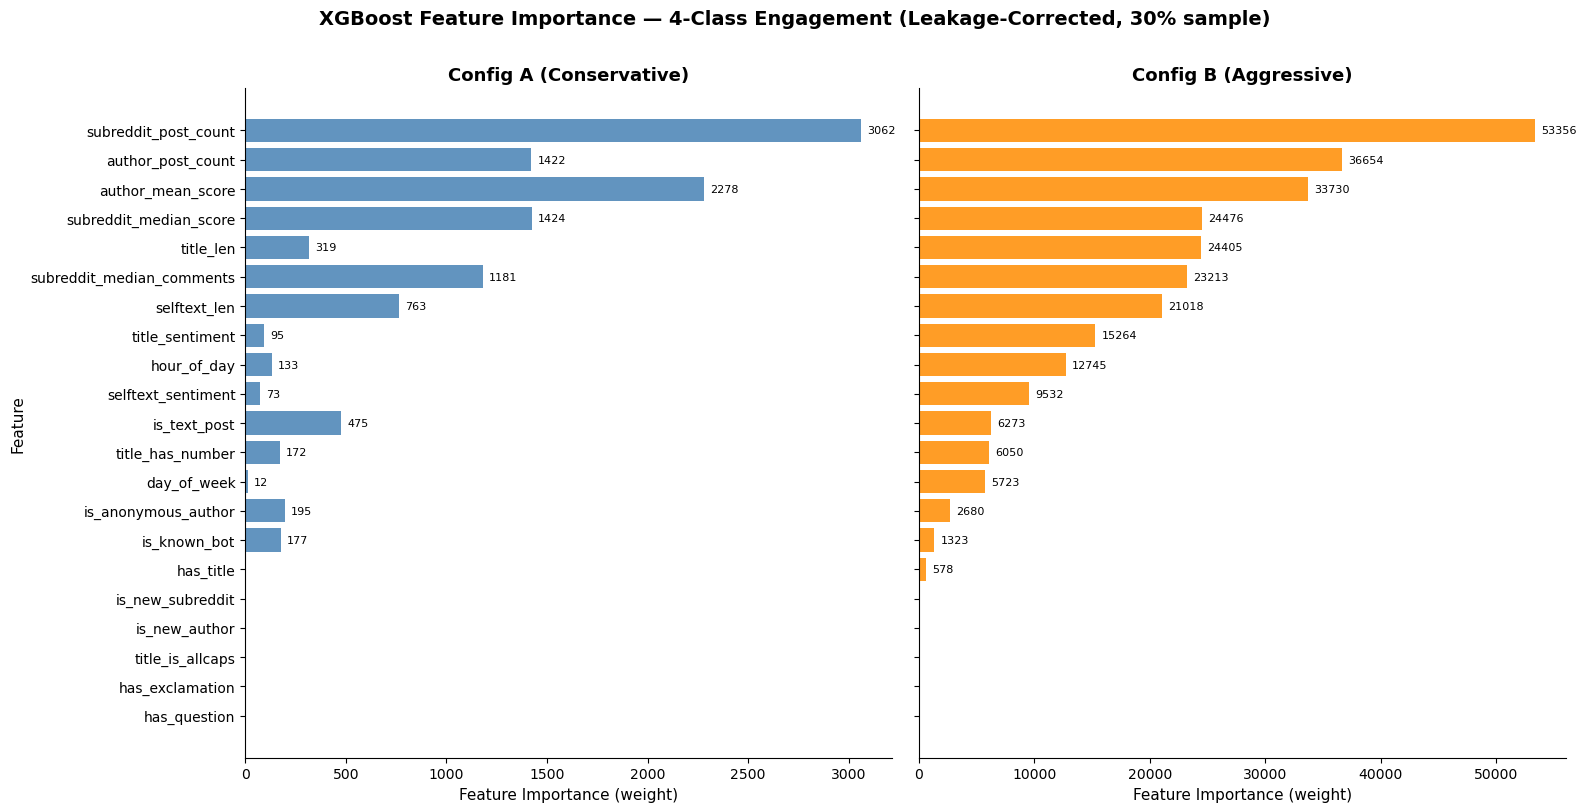

Saved xgb_v2_4class_feature_importance.png


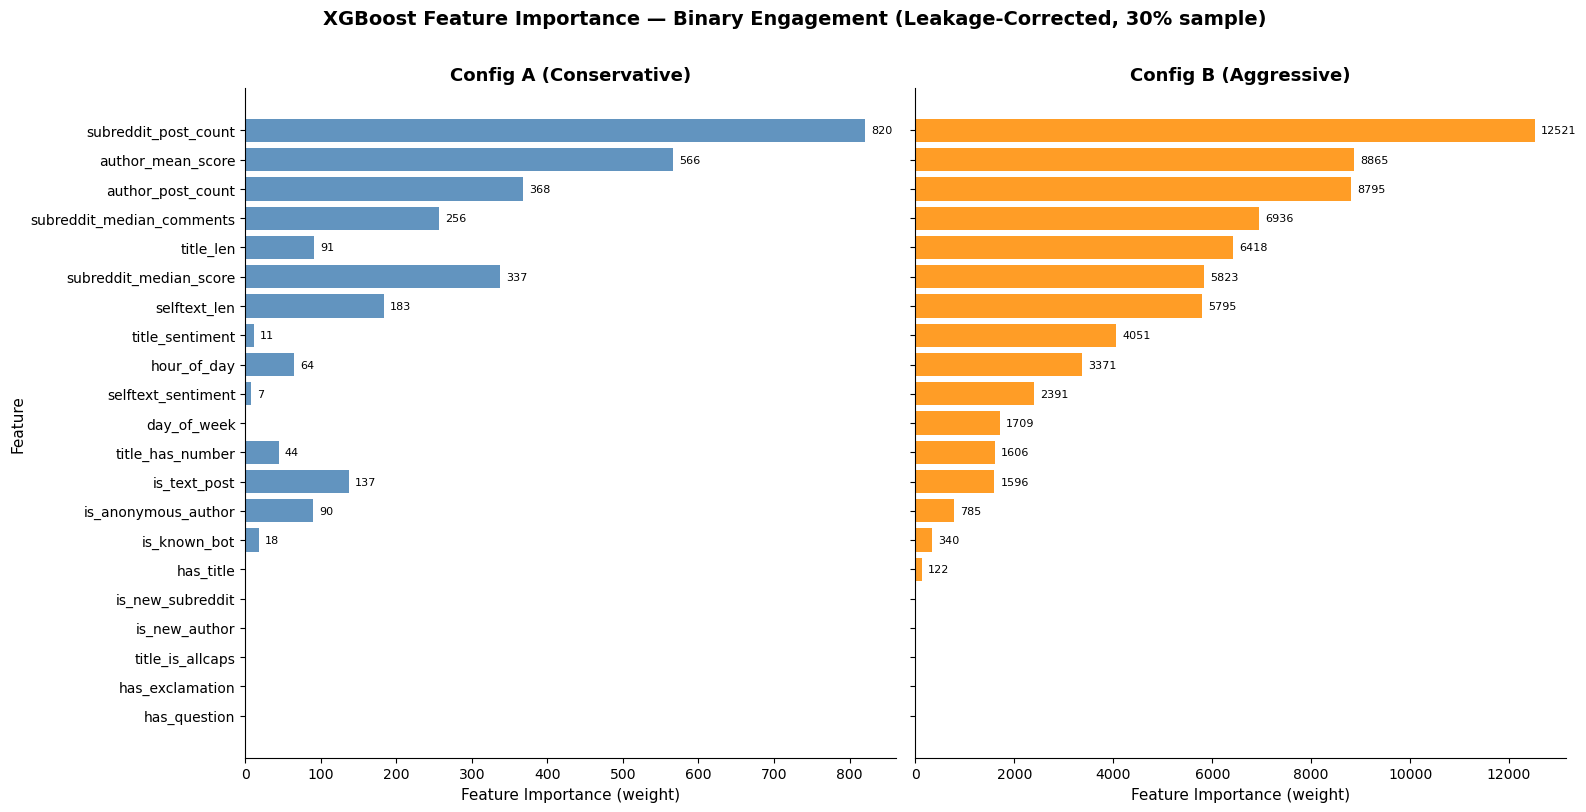

Saved xgb_v2_binary_feature_importance.png


In [13]:
# ── FEATURE IMPORTANCE PLOTS (4-class and binary) ────────────────────────────
import matplotlib.pyplot as plt
import os

os.makedirs("../outputs/figures", exist_ok=True)

# Must match the VectorAssembler input order exactly (21 features)
FEATURE_NAMES = [
    "title_len", "has_question", "has_exclamation", "title_has_number", "title_is_allcaps",
    "has_title", "is_text_post", "selftext_len",
    "hour_of_day", "day_of_week",
    "is_known_bot", "is_anonymous_author",
    "is_new_author", "is_new_subreddit",
    "author_post_count", "author_mean_score",
    "subreddit_post_count", "subreddit_median_score", "subreddit_median_comments",
    "title_sentiment", "selftext_sentiment",
]

def importance_dict(model, names):
    scores = model.get_booster().get_score(importance_type="weight")
    imp = {names[int(k[1:])]: v for k, v in scores.items()}
    return {n: imp.get(n, 0) for n in names}

def plot_importance(model_A, model_B, task, fname):
    iA = importance_dict(model_A, FEATURE_NAMES)
    iB = importance_dict(model_B, FEATURE_NAMES)
    order = sorted(FEATURE_NAMES, key=lambda f: iB[f])
    vA = [iA[f] for f in order]; vB = [iB[f] for f in order]
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
    for ax, vals, title, color in zip(axes, [vA, vB],
            ["Config A (Conservative)", "Config B (Aggressive)"], ["steelblue", "darkorange"]):
        bars = ax.barh(order, vals, color=color, alpha=0.85)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Feature Importance (weight)", fontsize=11)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_width() + max(vals)*0.01, bar.get_y()+bar.get_height()/2,
                        f"{int(val)}", va="center", fontsize=8)
    axes[0].set_ylabel("Feature", fontsize=11)
    plt.suptitle(f"XGBoost Feature Importance — {task} (Leakage-Corrected, 30% sample)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/{fname}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname}")

# Models A and B are in memory if eval ran in same session; else reload:
from xgboost.spark import SparkXGBClassifierModel
model_A     = SparkXGBClassifierModel.load("../models/xgb_4class_configA_v2/")
model_B     = SparkXGBClassifierModel.load("../models/xgb_4class_configB_v2/")
model_A_bin = SparkXGBClassifierModel.load("../models/xgb_binary_configA_v2/")
model_B_bin = SparkXGBClassifierModel.load("../models/xgb_binary_configB_v2/")

plot_importance(model_A, model_B, "4-Class Engagement", "xgb_v2_4class_feature_importance.png")
plot_importance(model_A_bin, model_B_bin, "Binary Engagement", "xgb_v2_binary_feature_importance.png")

### Fitting Analysis (Train vs. Validation vs. Test)

Weighted F1 across the three splits is plotted for both configurations and tasks to locate each model on the bias–variance spectrum. The v1 models underfit (train F1 below val/test). The leakage correction may alter this picture: removing leaked aggregates lowers the effective signal, and the cold-start gap between the train period and the later held-out periods is now explicit. Comparing the corrected fitting curve to v1's clarifies whether the earlier underfitting was genuine or partly an artifact of leakage inflating the held-out splits.

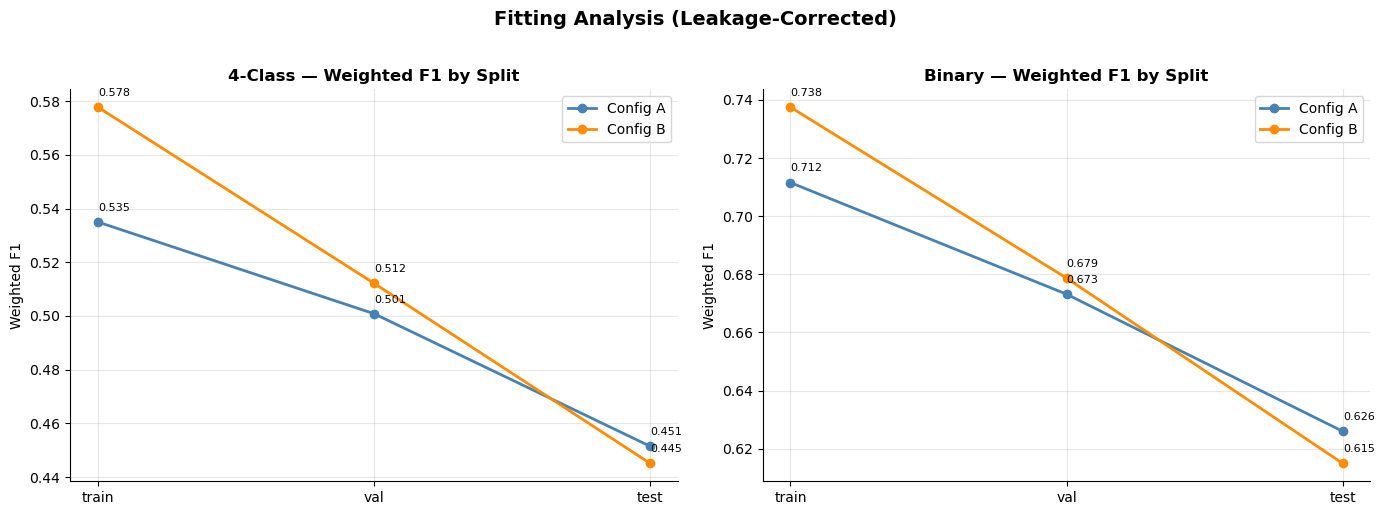

Saved fitting analysis plot.


In [14]:
# ── FITTING ANALYSIS PLOT (reads the persisted eval JSON) ────────────────────
import json, matplotlib.pyplot as plt

with open("../outputs/xgboost_v2_evaluation_results.json") as f:
    R = json.load(f)

splits = ["train", "val", "test"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (task, keys) in zip(axes, [("4-Class", ["4class_A", "4class_B"]),
                                    ("Binary", ["binary_A", "binary_B"])]):
    for key, label, color in zip(keys, ["Config A", "Config B"], ["steelblue", "darkorange"]):
        if key in R:
            y = [R[key][s]["overall"]["f1"] for s in splits]
            ax.plot(splits, y, marker="o", label=label, color=color, linewidth=2)
            for s, v in zip(splits, y):
                ax.annotate(f"{v:.3f}", (s, v), textcoords="offset points", xytext=(0, 8), fontsize=8)
    ax.set_title(f"{task} — Weighted F1 by Split", fontsize=12, fontweight="bold")
    ax.set_ylabel("Weighted F1"); ax.legend(); ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.suptitle("Fitting Analysis (Leakage-Corrected)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/xgb_v2_fitting_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fitting analysis plot.")

### Leakage-Corrected Baseline Results

The corrected XGBoost models reveal that temporal aggregate leakage was responsible for a substantial fraction of Milestone 3's reported performance:

| Task | v1 Test WF1 (leaky) | v2 Test WF1 (corrected) | Δ |
|---|---|---|---|
| 4-class Config A | 0.5689 | 0.4514 | **−0.118** |
| 4-class Config B | 0.5866 | 0.4451 | **−0.142** |
| Binary Config A   | 0.7280 | 0.6260 | **−0.102** |
| Binary Config B   | 0.7440 | 0.6149 | **−0.129** |

Roughly 10–14 weighted-F1 points of v1's reported test performance were attributable to temporal aggregate leakage rather than genuine pre-publication signal. The leakage arose from computing author and subreddit aggregates (`author_mean_score`, `subreddit_median_score`, etc.) over the full 2012–2018 dataset before the temporal split, allowing each validation and test row to access summary statistics that included information from its own period.

**Configuration ranking reverses on test.** In v1, the aggressive Config B outperformed the conservative Config A across all splits. With the leakage removed, Config A now achieves higher test weighted F1 than Config B for both tasks (4-class: 0.4514 vs 0.4451; binary: 0.6260 vs 0.6149), even as Config B retains the higher train weighted F1. This indicates that v1's Config B was effectively overfitting to the leaked aggregate signal: with deeper trees and lighter regularization, it absorbed more of the spurious information that did not generalize to the held-out periods. The conservative Config A, which placed less weight on these features under v1, generalizes better once the signal is honest.

**The train→test gap tracks cold-start prevalence.** All four models show a substantial monotonic decline from train to validation to test (Config B 4-class: 0.578 → 0.512 → 0.445; binary: 0.738 → 0.679 → 0.615). The training split has 0% cold-start by construction, the validation split has 28.8% cold-start authors, and the test split has 48.6%. The performance degradation tracks this prevalence almost linearly, indicating that the test underperformance is not classical overfitting but a structural consequence of forward-in-time prediction on a growing platform: roughly half of the test set consists of authors with no training-period history available, and the model has no historical basis to ground predictions for them. This finding directly motivates the dimensionality-reduced NLP feature enrichment in Milestone 4, since content-derived features (TF-IDF, SVD components, embeddings) carry signal independent of author history and are the principal recourse for the cold-start population.

**Feature importance is dominated by subreddit and author aggregates.** As in v1, `subreddit_post_count`, `author_post_count`, `author_mean_score`, and `subreddit_median_score` are the top features across all four models, with title-structural features (`title_len`, `selftext_len`) and sentiment (`title_sentiment`, `selftext_sentiment`) forming the second tier. The cold-start flags `is_new_author` and `is_new_subreddit` show zero importance — by design, both are identically zero on the training data (every train author/subreddit is in the train aggregate by construction), giving XGBoost no variance to split on at training time. XGBoost's native missing-value default-direction handling carries the actual cold-start routing through its built-in NaN logic, rendering the explicit flags structurally redundant. The flags are retained in the feature set for transparency and would become informative under a different split structure (e.g. k-fold cross-validation) where cold-start status varies within training data.

Several low-information features show zero importance across all models: `has_title`, `title_is_allcaps`, `has_exclamation`, and `has_question`. These are candidates for removal in subsequent modeling stages.

### Sanity Check: Verify Low-Information Features Before NLP Augmentation

Four structural features show zero importance across all four models (`has_title`, `title_is_allcaps`, `has_exclamation`, `has_question`). Before committing to the augmented feature set for the NLP-enriched models, we verify this is consistent rather than a single-model artifact by examining the importance across all four models simultaneously. Features with zero importance in every model are candidates for removal: keeping them adds vector dimensionality without information, and (depending on `colsample_bytree`) can mildly degrade training by occupying sampled-feature slots with noise.

The cold-start flags `is_new_author` and `is_new_subreddit` also show zero importance, but for a structurally different reason: they are identically zero on the training data (every train author and subreddit is in the train aggregate by construction), so XGBoost has no variance to split on. They are retained to document the cold-start methodology in the assembler and to remain available under any future modeling structure where cold-start status varies within training data.

In [3]:
# ── SANITY CHECK: ZERO-IMPORTANCE FEATURES ACROSS ALL FOUR MODELS ────────────
# Confirm the candidates for removal are zero (or near-zero) in EVERY model,
# not just dominant ones, before deciding to drop them.

import pandas as pd
from xgboost.spark import SparkXGBClassifierModel

MODELS_FOR_AUDIT = {
    "4class_A": "../models/xgb_4class_configA_v2/",
    "4class_B": "../models/xgb_4class_configB_v2/",
    "binary_A": "../models/xgb_binary_configA_v2/",
    "binary_B": "../models/xgb_binary_configB_v2/",
}

def importance_dict(model, names):
    scores = model.get_booster().get_score(importance_type="weight")
    imp = {names[int(k[1:])]: v for k, v in scores.items()}
    return {n: imp.get(n, 0) for n in names}

# Already-defined FEATURE_NAMES from the importance-plot cell; redefining for safety
FEATURE_NAMES = [
    "title_len", "has_question", "has_exclamation", "title_has_number", "title_is_allcaps",
    "has_title", "is_text_post", "selftext_len",
    "hour_of_day", "day_of_week",
    "is_known_bot", "is_anonymous_author",
    "is_new_author", "is_new_subreddit",
    "author_post_count", "author_mean_score",
    "subreddit_post_count", "subreddit_median_score", "subreddit_median_comments",
    "title_sentiment", "selftext_sentiment",
]

rows = {}
for key, path in MODELS_FOR_AUDIT.items():
    m = SparkXGBClassifierModel.load(path)
    rows[key] = importance_dict(m, FEATURE_NAMES)

df_imp = pd.DataFrame(rows).fillna(0)
df_imp["min"] = df_imp.min(axis=1)
df_imp["max"] = df_imp.max(axis=1)
df_imp = df_imp.sort_values("max")

print("Feature importance across all four models (sorted ascending by max):")
print(df_imp.to_string())

zero_in_all = df_imp[df_imp["max"] == 0].index.tolist()
print(f"\nFeatures with zero importance in EVERY model ({len(zero_in_all)}):")
for f in zero_in_all:
    print(f"  - {f}")

Feature importance across all four models (sorted ascending by max):
                           4class_A  4class_B  binary_A  binary_B    min      max
has_question                    0.0       0.0       0.0       0.0    0.0      0.0
has_exclamation                 0.0       0.0       0.0       0.0    0.0      0.0
title_is_allcaps                0.0       0.0       0.0       0.0    0.0      0.0
is_new_subreddit                0.0       0.0       0.0       0.0    0.0      0.0
is_new_author                   0.0       0.0       0.0       0.0    0.0      0.0
has_title                       0.0     578.0       0.0     122.0    0.0    578.0
is_known_bot                  177.0    1323.0      18.0     340.0   18.0   1323.0
is_anonymous_author           195.0    2680.0      90.0     785.0   90.0   2680.0
day_of_week                    12.0    5723.0       0.0    1709.0    0.0   5723.0
title_has_number              172.0    6050.0      44.0    1606.0   44.0   6050.0
is_text_post                 

**Feature importance audit complete.** Examining feature importance across all four trained models simultaneously confirms five features with zero importance in every model: three title-structural features (`has_question`, `has_exclamation`, `title_is_allcaps`) and the two cold-start flags (`is_new_author`, `is_new_subreddit`). A fourth title-structural feature, `has_title`, is zero-importance in both Config A models but receives marginal weight in Config B (578 and 122 splits, ~1% of the top feature's count), exclusively in the more aggressive configuration — the regime most prone to finding spurious splits on near-constant features. Because `has_title = 1` for the overwhelming majority of rows and the rare zero-title cases are already captured by `title_len = 0`, this signal is redundant with `title_len` and is also removed.

The cold-start flags are retained despite zero importance: they encode no information during training (every train row by construction has `is_new_author = 0`), so XGBoost cannot split on them, but their presence in the feature vector documents the cold-start methodology and they would become informative under any modeling structure where cold-start status varies within the training data. XGBoost's native missing-value default-direction handling provides the actual cold-start routing through its built-in NaN logic.

Final structured feature set for the NLP-enriched pipeline: **17 features**, removing `has_title`, `has_question`, `has_exclamation`, and `title_is_allcaps` from the original 21. The reduced vector will be concatenated with SVD components from TF-IDF dimensionality reduction in Milestone 4.

## Milestone 3 Conclusion

The headline result of Milestone 3 is methodological: a temporal aggregate leakage bug in the original pipeline was responsible for roughly 10–14 weighted-F1 points of reported test performance across all four model configurations. Computing author and subreddit aggregates (`author_mean_score`, `subreddit_median_score`, etc.) over the full 2012–2018 dataset before the temporal split allowed each validation and test row to access summary statistics that included information from its own period. Correcting this by computing aggregates strictly on training-period data — and explicitly handling the resulting cold-start cases via XGBoost's native missing-value mechanism — produced a corrected baseline that is meaningfully lower than the original numbers but is, for the first time, an honest measurement of forward-in-time generalization.

Three findings emerged from the corrected pipeline:

**The leakage was severe and uniform.** Test weighted F1 dropped 0.10–0.14 across all four model configurations, with the heaviest impact on the more aggressive Config B. The four trained XGBoost models now report test weighted F1 of 0.4514 (4-class A), 0.4451 (4-class B), 0.6260 (binary A), and 0.6149 (binary B), versus v1's 0.5689 / 0.5866 / 0.7280 / 0.7440. The proportional reduction is consistent across tasks, which is what we would expect from a leakage source affecting all models equally rather than a model-specific issue.

**Configuration ranking inverts on test.** In v1, the aggressive Config B outperformed the conservative Config A across the board. With the leakage removed, Config A now achieves the higher test weighted F1 in both tasks, even as Config B retains the higher train weighted F1. This is a textbook signature of overfitting to a spurious feature: with deeper trees and lighter regularization, Config B absorbed more of the leaked aggregate signal — signal that did not generalize once removed. The conservative configuration, which under-relied on the leaky features by virtue of its regularization, generalizes better when the signal is honest.

**The train→test gap reflects cold-start prevalence, not classical overfitting.** Performance declines monotonically from train (0% cold-start by construction) to validation (28.8% cold-start authors) to test (48.6%), tracking the cold-start rate almost linearly. Roughly half of the 2018 test set consists of authors with no training-period history, and the model has no historical basis to ground predictions for them. This is not a model failure but a structural property of forward-in-time prediction on a growing platform — and it is the result that directly motivates Milestone 4's content-based feature enrichment, since text features (TF-IDF components, embeddings) carry signal that does not depend on author history.

**On the implementation side**, the corrected pipeline required several non-obvious engineering changes. The aggregate join had to be lineage-broken via disk round-trip to avoid Spark's shared-plan resolution silently returning nulls for valid keys (the first attempt produced an impossible 86% cold-start rate on training data). The sentiment lookup had to be deduplicated to handle the dataset's single known duplicate post id, which would otherwise have fanned out test rows on a left join. The XGBoost training step OOM'd in `local[*]` mode on the full 276M-row training set, requiring a stratified 30% sample (82.9M rows) for model fitting; the sample preserves class proportions to four decimals so reported metrics are not biased by sampling variance. The feature assembler was set to `handleInvalid="keep"` so cold-start rows (up to 48.6% of test) are preserved in the output with their missing aggregates represented as NaN, which XGBoost handles natively via its learned default-direction mechanism — a critical detail since the alternative (`handleInvalid="skip"`) would have silently dropped nearly half the test set.

**What's next.** Milestone 4 introduces dimensionality reduction on a content-derived feature space, with the M4 model trained on the reduced features. As preparation, the present notebook is extended below with TF-IDF feature engineering and (time permitting) truncated SVD, producing an enriched feature artifact that M4 will both *use* and *analyze* in the formal dimensionality-reduction framing required by the rubric. The structural-feature-only baseline established above remains the reference against which the NLP-enriched model is measured: any test weighted F1 gain in the NLP arm is, by construction, attributable to content features rather than feature engineering of the existing structured set.

## Extension: TF-IDF Feature Engineering for the NLP Arm

The Milestone 3 deliverable is complete above. The remainder of this notebook extends the pipeline with TF-IDF feature engineering and, time permitting, truncated SVD dimensionality reduction. The motivation is structural: roughly half the test set consists of cold-start authors for whom the historical aggregate features carry no information, so content-derived features are the principal lever for further improvement. The TF-IDF artifact persisted below is the input to Milestone 4's dimensionality reduction analysis and supervised model on reduced features.

Four zero-importance structural features (`has_title`, `has_question`, `has_exclamation`, `title_is_allcaps`) identified in the importance audit above are excluded from the NLP-enriched feature set. The cold-start flags (`is_new_author`, `is_new_subreddit`) are retained despite zero importance, since they document the cold-start methodology and may become informative under different modeling structures.

### TF-IDF Feature Engineering (Title)

Term frequency–inverse document frequency features are computed on post titles. The IDF model is fit on the 30% stratified training sample (`train_sample30_v2`) and then applied to all three full-size splits, preserving the train-only leakage discipline established for the aggregate features. Titles are lowercased, tokenized on non-alphanumeric boundaries, and stop-words are removed before hashing.

`HashingTF` is used in place of `CountVectorizer` to produce a fixed-width 10,000-dimensional vector in a single pass, avoiding the full-vocabulary materialization that `CountVectorizer` would require over 535M documents. The resulting sparse TF-IDF vector is persisted alongside the existing structured features and will be reduced via truncated SVD in the next step before being combined with the structured feature vector for XGBoost training.

Selftext is excluded from this pass: ~36% of rows are link posts with no body, and title alone is the cleaner first experiment. A title+selftext variant can be layered in subsequently if time permits.

In [4]:
# ── RELOAD ASSEMBLED SPLITS + TRAIN SAMPLE ───────────────────────────────────
TRAIN_MODEL_DIR  = "../data/processed/train_model_v2/"
VAL_MODEL_DIR    = "../data/processed/val_model_v2/"
TEST_MODEL_DIR   = "../data/processed/test_model_v2/"
TRAIN_SAMPLE_DIR = "../data/processed/train_sample30_v2/"

train_split  = spark.read.parquet(TRAIN_MODEL_DIR)
val_split    = spark.read.parquet(VAL_MODEL_DIR)
test_split   = spark.read.parquet(TEST_MODEL_DIR)
train_sample = spark.read.parquet(TRAIN_SAMPLE_DIR)

print(f"Train full:    {train_split.count():,}")
print(f"Val:           {val_split.count():,}")
print(f"Test:          {test_split.count():,}")
print(f"Train sample:  {train_sample.count():,}")

Train full:    276,442,594
Val:           114,089,205
Test:          144,949,019
Train sample:  82,930,798


In [5]:
# ── TF-IDF PIPELINE: tokenize → stopwords → HashingTF → IDF (train-only fit) ──
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml import Pipeline

N_HASH_FEATURES = 10000

# Lowercase tokenize on non-alphanumeric boundaries
tokenizer = RegexTokenizer(
    inputCol="title", outputCol="title_tokens",
    pattern=r"\W+", toLowercase=True, minTokenLength=2,
)

# Standard English stopwords
stopwords = StopWordsRemover(
    inputCol="title_tokens", outputCol="title_tokens_clean",
)

# Hashing TF — single-pass, fixed-width sparse output
hashing_tf = HashingTF(
    inputCol="title_tokens_clean", outputCol="title_tf",
    numFeatures=N_HASH_FEATURES,
)

# IDF re-weights by inverse document frequency
idf = IDF(inputCol="title_tf", outputCol="title_tfidf", minDocFreq=5)

# Fit pipeline on TRAIN SAMPLE only — preserves train-only discipline.
# Tokenizer and StopWordsRemover have no fitted state but are part of the pipeline
# for ordering; HashingTF has no fitted state (deterministic hash); IDF is the
# only stage that actually learns from data.
tfidf_pipeline = Pipeline(stages=[tokenizer, stopwords, hashing_tf, idf])

print("Fitting TF-IDF pipeline on train sample (82.9M rows)...")
import time, datetime
t0 = time.time()
tfidf_model = tfidf_pipeline.fit(train_sample)
print(f"[{datetime.datetime.now():%H:%M:%S}] Fit complete in "
      f"{int((time.time()-t0)//60)}m {int((time.time()-t0)%60)}s")

# Persist the fitted model for reproducibility
TFIDF_MODEL_DIR = "../models/tfidf_title_v2/"
tfidf_model.write().overwrite().save(TFIDF_MODEL_DIR)
print(f"Saved -> {TFIDF_MODEL_DIR}")

Fitting TF-IDF pipeline on train sample (82.9M rows)...
[19:44:33] Fit complete in 1m 54s
Saved -> ../models/tfidf_title_v2/


In [6]:
# ── TRANSFORM ALL THREE SPLITS + PERSIST ─────────────────────────────────────
# Apply the train-fitted IDF model to full-size train/val/test.
# We persist with the existing model-ready columns intact so the next step
# (SVD, then XGBoost retrain) can load this directly.

TRAIN_TFIDF_DIR = "../data/processed/train_tfidf_v2/"
VAL_TFIDF_DIR   = "../data/processed/val_tfidf_v2/"
TEST_TFIDF_DIR  = "../data/processed/test_tfidf_v2/"

# Drop intermediate token columns to keep parquet size manageable
KEEP_COLS = [c for c in train_split.columns]  # all existing columns
KEEP_COLS_OUT = KEEP_COLS + ["title_tfidf"]

def transform_and_persist(df, out_dir, name):
    print(f"[{datetime.datetime.now():%H:%M:%S}] Transforming {name}...")
    t0 = time.time()
    transformed = tfidf_model.transform(df).select(*KEEP_COLS_OUT)
    transformed.write.mode("overwrite").parquet(out_dir)
    print(f"[{datetime.datetime.now():%H:%M:%S}] {name} done in "
          f"{int((time.time()-t0)//60)}m {int((time.time()-t0)%60)}s")

transform_and_persist(train_split, TRAIN_TFIDF_DIR, "train")
transform_and_persist(val_split,   VAL_TFIDF_DIR,   "val")
transform_and_persist(test_split,  TEST_TFIDF_DIR,  "test")

print("\nReloading from disk to break lineage...")
train_tfidf = spark.read.parquet(TRAIN_TFIDF_DIR)
val_tfidf   = spark.read.parquet(VAL_TFIDF_DIR)
test_tfidf  = spark.read.parquet(TEST_TFIDF_DIR)

for name, df, expected in [("train", train_tfidf, 276_442_594),
                            ("val",   val_tfidf,   114_089_205),
                            ("test",  test_tfidf,  144_949_019)]:
    n = df.count()
    flag = "OK" if n == expected else f"MISMATCH (expected {expected:,})"
    print(f"  {name}: {n:,} [{flag}]  cols={len(df.columns)}")

print(f"\nColumns: {train_tfidf.columns}")

[19:44:46] Transforming train...
[19:57:05] train done in 12m 18s
[19:57:05] Transforming val...
[20:01:20] val done in 4m 15s
[20:01:20] Transforming test...
[20:07:23] test done in 6m 2s

Reloading from disk to break lineage...
  train: 276,442,594 [OK]  cols=36
  val: 114,089,205 [OK]  cols=36
  test: 144,949,019 [OK]  cols=36

Columns: ['id', 'subreddit', 'author', 'num_comments', 'score', 'selftext', 'subreddit_id', 'title', 'created_utc', 'is_known_bot', 'is_anonymous_author', 'has_title', 'label_4class', 'label_binary', 'title_len', 'has_question', 'has_exclamation', 'title_has_number', 'title_is_allcaps', 'is_text_post', 'selftext_len', 'hour_of_day', 'day_of_week', 'author_post_count', 'author_mean_score', 'is_new_author', 'subreddit_post_count', 'subreddit_median_score', 'subreddit_median_comments', 'is_new_subreddit', 'title_sentiment', 'selftext_sentiment', 'label_4class_idx', 'label_binary_idx', 'features', 'title_tfidf']


## Extension: TF-IDF Feature Engineering (Milestone 4 Preparation)

Following the Milestone 3 conclusion, the notebook is extended with TF-IDF feature engineering on post titles. This work produces a new feature artifact — a 10,000-dimensional sparse TF-IDF vector — that serves as the input to the dimensionality reduction and supervised modeling work in Milestone 4. The motivation traces directly back to the cold-start finding: roughly half of test rows have authors with no training-period history, and content-derived features are the principal recourse for those rows.

The pipeline is `RegexTokenizer` → `StopWordsRemover` → `HashingTF(numFeatures=10000)` → `IDF(minDocFreq=5)`. `HashingTF` is used rather than `CountVectorizer` to avoid the full-vocabulary materialization that `CountVectorizer` would require over 535M documents. The IDF model is fit on the 30% stratified train sample, preserving the same train-only discipline established for the aggregate features, and applied to all three full-size splits. Selftext is excluded from this pass — ~36% of rows are link posts with no body, and title alone is the cleaner first experiment.

**Throughput.** The IDF fit on 82.9M training-sample titles completed in **1m 54s**. Transforming and persisting the three full splits (train 276M, val 114M, test 145M rows) completed in 12m 18s, 4m 15s, and 6m 2s respectively. Total TF-IDF stage elapsed time: roughly 25 minutes.

**Outputs.** The fitted pipeline is persisted at `models/tfidf_title_v2/`. The three transformed splits are persisted at `data/processed/{train,val,test}_tfidf_v2/`, each carrying all 35 columns from the model-ready splits plus the new `title_tfidf` sparse vector column.

This is the stopping point for Milestone 3. Milestone 4 begins from these TF-IDF artifacts: fitting truncated SVD via `RowMatrix.computeSVD` (Latent Semantic Analysis — the textbook SVD application for TF-IDF, and the API explicitly cited by the M4 rubric), analyzing the resulting explained variance and components, choosing a target dimensionality empirically, and training the supervised second model on the reduced feature set.

# V1 PIPELINE -- ALL CODE BELOW IS STALE -- PIPELINE CURRENTLY BEING RESTRUCTURED -- DISREGARD ALL BELOW

# --------------------------------------------------------------------------------------------------

## Feature Engineering

All features are derived from pre-publication information only to prevent data leakage and no features use `score`, `num_comments`, or the derived label columns.

### Title and Post Type Features

Simple structural features extracted from the `title` and `selftext` columns using PySpark string functions. These require no aggregations or UDFs and are computed directly as column transformations. Both text length features use character count for consistency.

- `title_len`: character count of the post title
- `has_question`: binary flag indicating the presence of `?` in the title
- `has_exclamation`: binary flag indicating the presence of `!` in the title
- `title_has_number`: binary flag indicating the presence of a digit in the title, captures listicle-style titles ("10 things...") which are a known Reddit engagement pattern
- `title_is_allcaps`: binary flag indicating the entire title is uppercase, captures high emotional register posts
- `is_text_post`: binary flag, 1 if the post has a non-empty selftext body
- `selftext_len`: character length of selftext (0 for link posts)

## Model Preparation

With all non-NLP features engineered, we now prepare the DataFrame for MLlib model training. This involves four steps:

1. **Null imputation** — check for and impute any nulls in numeric feature columns
2. **Label encoding** — convert string labels to numeric indices using `StringIndexer`
3. **Feature assembly** — combine all numeric features into a single vector using `VectorAssembler`
4. **Feature scaling** — standardize the feature vector using `StandardScaler`

These steps follow feature engineering as they operate on the finalized feature set rather than raw data.

### Step 1 — Null Check on Feature Columns

Before assembling the feature vector, we check for nulls across all numeric feature columns. Nulls will cause `VectorAssembler` to fail unless handled explicitly via imputation or by setting `handleInvalid="skip"`. We use `Imputer` for numeric nulls rather than dropping rows, preserving as much data as possible.

In [25]:
# ── NULL CHECK ON FEATURE COLUMNS ────────────────────────────────────────────

feature_cols = [
    "title_len", "has_question", "has_exclamation",
    "title_has_number", "title_is_allcaps",
    "is_text_post", "selftext_len", "hour_of_day", "day_of_week",
    "subreddit_post_count", "subreddit_median_score", "subreddit_median_comments",
    "author_post_count", "author_mean_score",
    "has_title", "is_known_bot", "is_anonymous_author",
    "title_sentiment", "selftext_sentiment"
]

# Count nulls per feature column
null_counts = df_features.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in feature_cols
])

null_counts.show(vertical=True)

-RECORD 0------------------------------
 title_len                 | 0         
 has_question              | 0         
 has_exclamation           | 0         
 title_has_number          | 0         
 title_is_allcaps          | 0         
 is_text_post              | 0         
 selftext_len              | 0         
 hour_of_day               | 0         
 day_of_week               | 0         
 subreddit_post_count      | 0         
 subreddit_median_score    | 0         
 subreddit_median_comments | 0         
 author_post_count         | 0         
 author_mean_score         | 0         
 has_title                 | 0         
 is_known_bot              | 0         
 is_anonymous_author       | 0         
 title_sentiment           | 0         
 selftext_sentiment        | 388899527 



### Null Check Results

All feature columns are null-free except `selftext_sentiment` which has 388,899,527 nulls which is exactly as expected. This represents the 72.8% of posts that are link posts with empty selftext, for which sentiment is intentionally undefined rather than neutral. The `is_text_post` flag already captures this distinction so the model has the context to interpret imputed selftext sentiment values correctly.

Only `selftext_sentiment` requires imputation before feature assembly.

### Step 2 — Imputation

Only `selftext_sentiment` requires imputation — 388,899,527 nulls representing link posts with no body text. All other feature columns are null-free. We impute with the mean strategy, replacing nulls with the mean sentiment score of text posts. The `is_text_post` flag remains in the feature set so the model retains the ability to distinguish imputed values (link posts) from genuine neutral

In [26]:
# ── IMPUTATION ────────────────────────────────────────────────────────────────
from pyspark.ml.feature import Imputer

# Only selftext_sentiment has nulls — impute with mean of non-null values
imputer = Imputer(
    inputCols=["selftext_sentiment"],
    outputCols=["selftext_sentiment"],
    strategy="mean"
)

# Fit computes mean from non-null rows, transform fills nulls
imputer_model = imputer.fit(df_features)
df_features = imputer_model.transform(df_features)

# Verify no nulls remain
null_check = df_features.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in feature_cols
])
print("Null counts after imputation:")
null_check.show(vertical=True)

Null counts after imputation:
-RECORD 0------------------------
 title_len                 | 0   
 has_question              | 0   
 has_exclamation           | 0   
 title_has_number          | 0   
 title_is_allcaps          | 0   
 is_text_post              | 0   
 selftext_len              | 0   
 hour_of_day               | 0   
 day_of_week               | 0   
 subreddit_post_count      | 0   
 subreddit_median_score    | 0   
 subreddit_median_comments | 0   
 author_post_count         | 0   
 author_mean_score         | 0   
 has_title                 | 0   
 is_known_bot              | 0   
 is_anonymous_author       | 0   
 title_sentiment           | 0   
 selftext_sentiment        | 0   



### Step 3 — Label Encoding

MLlib classifiers require numeric labels. `StringIndexer` converts `label_4class` and `label_binary` string labels to numeric indices ordered by frequency. The most frequent label receives index 0. Given `low-engagement` is the plurality class at 44.3%, it is expected to receive index 0 in the 4-class encoding.

In [27]:
# ── LABEL ENCODING ───────────────────────────────────────────────────────────
from pyspark.ml.feature import StringIndexer

# Index 4-class label
indexer_4class = StringIndexer(
    inputCol="label_4class",
    outputCol="label_4class_idx",
    handleInvalid="keep"
)

# Index binary label
indexer_binary = StringIndexer(
    inputCol="label_binary",
    outputCol="label_binary_idx",
    handleInvalid="keep"
)

# Fit and transform
df_features = indexer_4class.fit(df_features).transform(df_features)
df_features = indexer_binary.fit(df_features).transform(df_features)

# Verify label index mapping
print("4-class label index mapping:")
df_features.groupBy("label_4class", "label_4class_idx") \
    .count() \
    .orderBy("label_4class_idx") \
    .show()

print("Binary label index mapping:")
df_features.groupBy("label_binary", "label_binary_idx") \
    .count() \
    .orderBy("label_binary_idx") \
    .show()

4-class label index mapping:
+--------------+----------------+---------+
|  label_4class|label_4class_idx|    count|
+--------------+----------------+---------+
|low-engagement|             0.0|236954268|
|         viral|             1.0|160168118|
| crowd-pleaser|             2.0| 74916114|
|debate-starter|             3.0| 63442318|
+--------------+----------------+---------+

Binary label index mapping:
+---------------+----------------+---------+
|   label_binary|label_binary_idx|    count|
+---------------+----------------+---------+
|high-engagement|             0.0|298526550|
| low-engagement|             1.0|236954268|
+---------------+----------------+---------+



### Label Encoding Results

Label indices assigned by frequency as expected:

**4-class:**
| Label | Index | Count |
|---|---|---|
| low-engagement | 0 | 236,954,268 |
| viral | 1 | 160,168,118 |
| crowd-pleaser | 2 | 74,916,114 |
| debate-starter | 3 | 63,442,318 |

**Binary:**
| Label | Index | Count |
|---|---|---|
| high-engagement | 0 | 298,526,550 |
| low-engagement | 1 | 236,954,268 |

`low-engagement` received index 0 in the 4-class encoding as predicted. Notably in the binary encoding, `high-engagement` is the majority class at 55.7% and receives index 0. Both encodings confirm the label distributions from the threshold analysis.

### Step 4 — Feature Assembly

`VectorAssembler` combines all 19 numeric feature columns into a single dense vector column required by MLlib models. Raw text columns (`title`, `selftext`), identifier columns (`id`, `author`, `subreddit`, `subreddit_id`), timestamp (`created_utc`), raw engagement columns (`score`, `num_comments`), and string label columns are excluded. Only engineered numeric features enter the vector. `handleInvalid="skip"` is set as a safety net though imputation above eliminated all nulls.

In [28]:
# ── FEATURE ASSEMBLY ──────────────────────────────────────────────────────────
from pyspark.ml.feature import VectorAssembler

assembler_cols = [
    # Title structural features
    "title_len", "has_question", "has_exclamation",
    "title_has_number", "title_is_allcaps",
    # Post type features
    "has_title", "is_text_post", "selftext_len",
    # Temporal features
    "hour_of_day", "day_of_week",
    # Author type flags
    "is_known_bot", "is_anonymous_author",
    # Author history aggregations
    "author_post_count", "author_mean_score",
    # Subreddit context aggregations
    "subreddit_post_count", "subreddit_median_score", "subreddit_median_comments",
    # NLP sentiment features
    "title_sentiment", "selftext_sentiment"
]

assembler = VectorAssembler(
    inputCols=assembler_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

df_features = assembler.transform(df_features)
print(f"Feature vector assembled with {len(assembler_cols)} features.")
df_features.select("features_raw").show(3, truncate=80)

Feature vector assembled with 19 features.
+--------------------------------------------------------------------------------+
|                                                                    features_raw|
+--------------------------------------------------------------------------------+
|(19,[0,3,5,8,9,12,13,14,15,18],[36.0,1.0,1.0,11.0,3.0,30.0,3.4,2473.0,1.0,0.2...|
|(19,[0,5,8,9,12,13,14,15,18],[36.0,1.0,20.0,6.0,30.0,3.4,2473.0,1.0,0.2330756...|
|(19,[0,5,8,9,12,13,14,15,16,18],[50.0,1.0,9.0,7.0,30.0,3.4,175729.0,3.0,3.0,0...|
+--------------------------------------------------------------------------------+
only showing top 3 rows



### Step 5 — Feature Scaling

`StandardScaler` standardizes the assembled feature vector to zero mean and unit variance. Features with large ranges (`author_post_count` can reach millions, `selftext_len` can reach thousands) would otherwise dominate binary features like `has_question` and `is_known_bot` which only take values 0 or 1. Scaling ensures all features contribute proportionally to the model.

The scaler is fit on training data only and applied to all three splits. Fitting on the full dataset would leak validation and test set statistics into training. We therefore perform the train/test split before fitting the scaler.

In [29]:
# ── TRAIN/VAL/TEST SPLIT ──────────────────────────────────────────────────────
from pyspark.ml.feature import StandardScaler

# Time-based split boundaries as Unix timestamps
TRAIN_END = 1483228800  # 2017-01-01 00:00:00 UTC
VAL_END   = 1514764800  # 2018-01-01 00:00:00 UTC

train_df = df_features.filter(F.col("created_utc") < TRAIN_END)
val_df   = df_features.filter(
    (F.col("created_utc") >= TRAIN_END) &
    (F.col("created_utc") < VAL_END)
)
test_df  = df_features.filter(F.col("created_utc") >= VAL_END)

print(f"Train rows: {train_df.count():,}")
print(f"Val rows:   {val_df.count():,}")
print(f"Test rows:  {test_df.count():,}")

# Fit scaler on training data only — prevents leakage from val/test sets
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(train_df)

# Apply fitted scaler to all three splits
train_df = scaler_model.transform(train_df)
val_df   = scaler_model.transform(val_df)
test_df  = scaler_model.transform(test_df)

print("\nScaling complete.")
print(f"Train rows: {train_df.count():,}")
print(f"Val rows:   {val_df.count():,}")
print(f"Test rows:  {test_df.count():,}")
train_df.select("features").show(3, truncate=80)

Train rows: 276,442,594
Val rows:   114,089,205
Test rows:  144,949,019

Scaling complete.
Train rows: 276,442,594
Val rows:   114,089,205
Test rows:  144,949,019
+--------------------------------------------------------------------------------+
|                                                                        features|
+--------------------------------------------------------------------------------+
|[-0.3794727388086728,0.0,0.0,1.8308506054916096,-0.07351652556800245,0.046569...|
|[-0.3794727388086728,0.0,0.0,-0.5461942079725822,-0.07351652556800245,0.04656...|
|[0.01009276171008487,0.0,0.0,-0.5461942079725822,-0.07351652556800245,0.04656...|
+--------------------------------------------------------------------------------+
only showing top 3 rows



### Scaling and Split Results

Time-based train/val/test split:

| Split | Rows | % of Total |
|---|---|---|
| Train (2012–2016) | 276,442,594 | 51.6% |
| Validation (2017) | 114,089,205 | 21.3% |
| Test (2018) | 144,949,019 | 27.1% |

The scaled feature vectors show standardized values centered around 0 with values both positive and negative, confirming `StandardScaler` is working correctly. The split proportions are reasonable with over half the data in training, with a full year each for validation and test.

### Persist Train/Val/Test Splits

We persist the three splits to disk before model training to break the lineage chain (features_nlp → imputer → StringIndexer → VectorAssembler → StandardScaler → time filter). Without persistence, every action during model training would re-execute this entire chain. Reading from persisted Parquet eliminates this overhead and significantly reduces training time.

In [30]:
# ── PERSIST TRAIN/VAL/TEST SPLITS ────────────────────────────────────────────

TRAIN_DIR = "../data/processed/train"
VAL_DIR   = "../data/processed/val"
TEST_DIR  = "../data/processed/test"

print("Writing train split...")
train_df.write.mode("overwrite").parquet(TRAIN_DIR)
print("Writing val split...")
val_df.write.mode("overwrite").parquet(VAL_DIR)
print("Writing test split...")
test_df.write.mode("overwrite").parquet(TEST_DIR)

print("\nReloading splits from disk...")
train_df = spark.read.parquet(TRAIN_DIR)
val_df   = spark.read.parquet(VAL_DIR)
test_df  = spark.read.parquet(TEST_DIR)

print(f"Train rows: {train_df.count():,}")
print(f"Val rows:   {val_df.count():,}")
print(f"Test rows:  {test_df.count():,}")

Writing train split...
Writing val split...
Writing test split...

Reloading splits from disk...
Train rows: 276,442,594
Val rows:   114,089,205
Test rows:  144,949,019


In [6]:
# Reloading train val and test dfs
# Note: This is checkpoint for model fitting; data load is done in persist cell
#       to validate counts

TRAIN_DIR = "../data/processed/train"
VAL_DIR   = "../data/processed/val"
TEST_DIR  = "../data/processed/test"


print("\nReloading splits from disk...")
train_df = spark.read.parquet(TRAIN_DIR)
val_df   = spark.read.parquet(VAL_DIR)
test_df  = spark.read.parquet(TEST_DIR)

print(f"Train rows: {train_df.count():,}")
print(f"Val rows:   {val_df.count():,}")
print(f"Test rows:  {test_df.count():,}")


Reloading splits from disk...
Train rows: 276,442,594
Val rows:   114,089,205
Test rows:  144,949,019


## Milestone 3: Model Training

We use `SparkXGBClassifier` from the `xgboost.spark` module, which ships with XGBoost ≥ 1.6. The cell below verifies availability and installs if needed.

In [7]:
# Check for XGBoost and Install if needed

try:
    from xgboost.spark import SparkXGBClassifier
    import xgboost as xgb
    print(f"XGBoost {xgb.__version__} available — SparkXGBClassifier ready")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost>=1.7"])
    from xgboost.spark import SparkXGBClassifier
    import xgboost as xgb
    print(f"Installed XGBoost {xgb.__version__}")

XGBoost 2.0.3 available — SparkXGBClassifier ready


### Class Weight Computation

To address label imbalance (low-engagement 44.3%, viral 29.9%, crowd-pleaser 14.0%, debate-starter 11.8%), we compute inverse-frequency weights from the training set only, then broadcast and join to all three splits. This prevents information leakage from val/test distributions into the weight values.

Weights are computed as `N / (num_classes * class_count)`, the normalized inverse frequency formulation used by scikit-learn, which keeps the effective total sample weight equal to N regardless of class distribution.

In [8]:
from pyspark.sql import functions as F

NUM_CLASSES_4 = 4
NUM_CLASSES_2 = 2

N_train = train_df.count()

# Compute per-class counts from train only
class_counts_4 = (
    train_df.groupBy("label_4class_idx")
            .agg(F.count("*").alias("class_count"))
)

class_counts_2 = (
    train_df.groupBy("label_binary_idx")
            .agg(F.count("*").alias("class_count"))
)

# Normalize: weight = N / (num_classes * class_count)
weight_map_4 = (
    class_counts_4
    .withColumn("weight_4class", F.lit(N_train) / (F.lit(NUM_CLASSES_4) * F.col("class_count")))
    .select("label_4class_idx", "weight_4class")
)

weight_map_2 = (
    class_counts_2
    .withColumn("weight_binary", F.lit(N_train) / (F.lit(NUM_CLASSES_2) * F.col("class_count")))
    .select("label_binary_idx", "weight_binary")
)

weight_map_4.orderBy("label_4class_idx").show()
weight_map_2.orderBy("label_binary_idx").show()

+----------------+------------------+
|label_4class_idx|     weight_4class|
+----------------+------------------+
|             0.0|0.5301268182465868|
|             1.0|0.9731065704183982|
|             2.0|1.6904547488515607|
|             3.0| 2.022386046668015|
+----------------+------------------+

+----------------+------------------+
|label_binary_idx|     weight_binary|
+----------------+------------------+
|             0.0|0.9462264655073706|
|             1.0|1.0602536364931736|
+----------------+------------------+



### Class Weight Results

The 4-class weights reflect the label imbalance introduced by the per-subreddit 75th-percentile thresholding scheme. Low-engagement (class 0) receives the smallest weight (0.530) because it is the majority class at 44.3% of the training set. Viral (class 1) is nearly balanced at 0.973, while crowd-pleaser (class 2, 14.0%) and debate-starter (class 3, 11.8%) receive the largest upweights (1.690 and 2.022 respectively) to compensate for their underrepresentation. The binary weights are close to 1.0 for both classes (0.946 and 1.060), consistent with a near-balanced binary split of 44.3% / 55.7% — the binary task requires minimal correction.

These weights will be passed to `SparkXGBClassifier` via `weight_col` so that the boosting objective penalizes misclassification of minority classes proportionally during tree construction.

### Joining Class Weights to Splits

We broadcast-join the 4-class and binary weight maps onto all three splits. The join is essentially free, both weight maps are 4 rows and 2 rows respectively, so Spark resolves them as broadcast hash joins with no shuffle.

After joining, we project each split down to only the three columns XGBoost needs (`features`, `label_4class_idx`, `weight_4class`). This avoids loading the full wide DataFrame which preserves all original columns including raw text and metadata into the XGBoost DMatrix during training, significantly reducing memory pressure on the JVM. The full-width `train_w`, `val_w`, and `test_w` are retained as lazy DataFrames for any post-hoc analysis in evaluation.

In [9]:
def attach_weights(df, wmap_4, wmap_2):
    return (
        df
        .join(F.broadcast(wmap_4), on="label_4class_idx", how="left")
        .join(F.broadcast(wmap_2), on="label_binary_idx", how="left")
    )

train_w = attach_weights(train_df, weight_map_4, weight_map_2)
val_w   = attach_weights(val_df,   weight_map_4, weight_map_2)
test_w  = attach_weights(test_df,  weight_map_4, weight_map_2)

# Project down to only what XGBoost needs — avoids loading wide DataFrame into DMatrix
train_xgb = train_w.select("features", "label_4class_idx", "weight_4class").repartition(16)
val_xgb   = val_w.select("features", "label_4class_idx", "weight_4class").repartition(16)
test_xgb  = test_w.select("features", "label_4class_idx", "weight_4class").repartition(16)

print("Weight join complete. Projected splits ready for training.")

Weight join complete. Projected splits ready for training.


In [10]:
print(f"train_xgb partitions: {train_xgb.rdd.getNumPartitions()}")
print(f"val_xgb partitions:   {val_xgb.rdd.getNumPartitions()}")
print(f"test_xgb partitions:  {test_xgb.rdd.getNumPartitions()}")

train_xgb partitions: 16
val_xgb partitions:   16
test_xgb partitions:  16


### XGBoost Model Configurations - 4-Class Model

We train two configurations on the 4-class problem to analyze the underfitting/overfitting tradeoff.

**Config A — Conservative (shallow, regularized):** `max_depth=4`, low learning rate, strong L2 regularization. Prioritizes stability; expected to underfit slightly given the complexity of 19 features across 102K subreddits.

**Config B — Aggressive (deep, fast learning):** `max_depth=8`, higher learning rate, light regularization. Risks overfitting on subreddit-level aggregation features that may encode training-period-specific behavior given the temporal train/val/test split.

Both configs target the 4-class label. `SparkXGBClassifier` sets the multiclass objective internally and uses `mlogloss` as the default evaluation metric — neither is passed explicitly. To avoid JVM OOM in `local[*]` mode, we use `num_workers=1` with `nthread=16` so XGBoost runs as a single worker using all 16 cores via multithreaded tree-building rather than 16 concurrent booster instances.

In [11]:
COMMON_PARAMS = dict(
    features_col="features",
    label_col="label_4class_idx",
    weight_col="weight_4class",
    num_class=4,
    num_workers=16, # Match partition size / core config
    device="cpu",
    seed=42,
)

# Config A: conservative — shallow trees, strong regularization
config_A = SparkXGBClassifier(
    **COMMON_PARAMS,
    max_depth=4,
    n_estimators=200,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    reg_alpha=1.0,
    min_child_weight=50,
)

# Config B: aggressive — deep trees, faster learning, light regularization
config_B = SparkXGBClassifier(
    **COMMON_PARAMS,
    max_depth=8,
    n_estimators=300,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=10,
)

print("Config A and Config B defined.")

Config A and Config B defined.


### Training Config A (Conservative)

SparkXGBClassifier distributes tree-building across 16 Spark workers, each processing ~17M rows in parallel within the single JVM. Open the Spark UI at port 4040 during training to capture the parallelism screenshot required by the milestone.

In [12]:
# Create directories

import os
os.makedirs("../outputs/models/xgb_config_A_checkpoints", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)

In [14]:
import time

print("Training Config A...")
t0 = time.time()

model_A = config_A.fit(train_xgb)
elapsed_A = time.time() - t0
print(f"Config A training time: {elapsed_A:.1f}s")

model_A.write().overwrite().save("../outputs/models/xgb_config_A")
print("Config A saved.")

Training Config A...


2026-05-09 01:33:24,408 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 50, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'subsample': 0.8, 'num_class': 4, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 200}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-09 02:32:05,254 INFO XGBoost-PySpark: _fit Finished xgboost training!


Config A training time: 3610.9s
Config A saved.


#### Spark UI — Executor Summary

Querying the Spark REST API to document executor configuration and confirm distributed execution for Config A.

In [15]:
import requests
import pandas as pd

sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

executors = requests.get(url).json()

sparkUI_df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
sparkUI_df['maxMemory_GB'] = (sparkUI_df['maxMemory'] / (1024**3)).round(2)
print(sparkUI_df)
print(f"\nSpark master: {sc.master}")

       id  totalCores    maxMemory  activeTasks  isActive  maxMemory_GB
0  driver          16  77120667648            0      True         71.82

Spark master: local[*]


### Training Config B (Aggressive)

Same distributed setup as Config A w/ 16 workers each processing ~17M rows. Deeper trees and faster learning rate are expected to produce a larger model with longer training time.

In [16]:
import time

print("Training Config B...")
t0 = time.time()

model_B = config_B.fit(train_xgb)
elapsed_B = time.time() - t0
print(f"Config B training time: {elapsed_B:.1f}s")

model_B.write().overwrite().save("../outputs/models/xgb_config_B")
print("Config B saved.")

Training Config B...


2026-05-09 03:47:32,161 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.7, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 10, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.7, 'num_class': 4, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-09 05:43:11,075 INFO XGBoost-PySpark: _fit Finished xgboost training!


Config B training time: 7059.0s
Config B saved.


### Reloading Persisted Models

Both configs trained and saved in the previous session. Loading directly from disk to proceed with evaluation.

In [9]:
from xgboost.spark import SparkXGBClassifierModel

model_A = SparkXGBClassifierModel.load("../outputs/models/xgb_config_A")
model_B = SparkXGBClassifierModel.load("../outputs/models/xgb_config_B")

print("Config A and Config B loaded successfully.")

Config A and Config B loaded successfully.


### Evaluation

We evaluate both models across all three splits using weighted F1, accuracy, weighted precision, and weighted recall. Per-class precision, recall, and F1 are derived from the confusion matrix directly, which is reliable across all Spark versions. The train/val/test error gap is the primary diagnostic for over and underfitting.

In [8]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

def evaluate_model(model, df, label_col="label_4class_idx", split_name=""):
    preds = model.transform(df)
    
    # Overall metrics via MLlib evaluator
    evaluator = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
    )
    metrics = {}
    for metric in ("f1", "accuracy", "weightedPrecision", "weightedRecall"):
        evaluator.setMetricName(metric)
        metrics[metric] = evaluator.evaluate(preds)

    # Per-class metrics via confusion matrix — reliable across all Spark versions
    preds_and_labels = preds.select("prediction", label_col) \
                            .rdd.map(lambda r: (float(r[0]), float(r[1])))
    mm = MulticlassMetrics(preds_and_labels)
    
    per_class = {}
    for cls in range(4):
        per_class[cls] = {
            "precision": round(mm.precision(float(cls)), 4),
            "recall":    round(mm.recall(float(cls)), 4),
            "f1":        round(mm.fMeasure(float(cls)), 4),
        }

    print(f"\n--- {split_name} ---")
    print(f"  Weighted F1:    {metrics['f1']:.4f}")
    print(f"  Accuracy:       {metrics['accuracy']:.4f}")
    print(f"  W-Precision:    {metrics['weightedPrecision']:.4f}")
    print(f"  W-Recall:       {metrics['weightedRecall']:.4f}")
    print(f"  Per-class metrics:")
    for cls, m in per_class.items():
        label = {0: "low-engagement", 1: "viral", 2: "crowd-pleaser", 3: "debate-starter"}[cls]
        print(f"    {label:20s} P={m['precision']}  R={m['recall']}  F1={m['f1']}")
    
    return metrics, per_class

results = {}
for name, model in [("A", model_A), ("B", model_B)]:
    print(f"\n====== Config {name} ======")
    tr_m,  tr_pc  = evaluate_model(model, train_xgb, split_name="Train")
    val_m, val_pc = evaluate_model(model, val_xgb,   split_name="Val")
    te_m,  te_pc  = evaluate_model(model, test_xgb,  split_name="Test")
    results[name] = {"train": tr_m, "val": val_m, "test": te_m}


====== Config A ======


/usr/local/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



--- Train ---
  Weighted F1:    0.5283
  Accuracy:       0.5049
  W-Precision:    0.5911
  W-Recall:       0.5049
  Per-class metrics:
    low-engagement       P=0.7309  R=0.5075  F1=0.599
    viral                P=0.6517  R=0.504  F1=0.5684
    crowd-pleaser        P=0.3324  R=0.5345  F1=0.4099
    debate-starter       P=0.2417  R=0.4615  F1=0.3172

--- Val ---
  Weighted F1:    0.5759
  Accuracy:       0.5531
  W-Precision:    0.6270
  W-Recall:       0.5531
  Per-class metrics:
    low-engagement       P=0.7287  R=0.5146  F1=0.6032
    viral                P=0.747  R=0.6574  F1=0.6993
    crowd-pleaser        P=0.3408  R=0.487  F1=0.401
    debate-starter       P=0.2364  R=0.4555  F1=0.3113

--- Test ---
  Weighted F1:    0.5689
  Accuracy:       0.5463
  W-Precision:    0.6111
  W-Recall:       0.5463
  Per-class metrics:
    low-engagement       P=0.7059  R=0.5393  F1=0.6115
    viral                P=0.7402  R=0.6538  F1=0.6943
    crowd-pleaser        P=0.2935  R=0.3767  F1=0.

### Persisting Evaluation Results

Evaluation results are saved to disk to avoid re-running the full scoring pipeline across 535M rows on every kernel restart.

In [9]:
import json

RESULTS_PATH = "../outputs/xgboost_4class_evaluation_results.json"

# Convert results dict to JSON-serializable format
results_serializable = {
    config: {
        split: {
            metric: float(val)
            for metric, val in metrics.items()
        }
        for split, metrics in splits.items()
    }
    for config, splits in results.items()
}

with open(RESULTS_PATH, "w") as f:
    json.dump(results_serializable, f, indent=2)

print(f"Results saved to {RESULTS_PATH}")

Results saved to ../outputs/xgboost_4class_evaluation_results.json


In [3]:
# Reload Results JSON 

import json

RESULTS_PATH = "../outputs/xgboost_4class_evaluation_results.json"

with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

print("Results loaded from disk.")
print(json.dumps(results, indent=2))

Results loaded from disk.
{
  "A": {
    "train": {
      "f1": 0.5283424471810294,
      "accuracy": 0.5048856400182672,
      "weightedPrecision": 0.5911198128323302,
      "weightedRecall": 0.5048856400182673
    },
    "val": {
      "f1": 0.5759404285528308,
      "accuracy": 0.5531042222618696,
      "weightedPrecision": 0.6270222511990466,
      "weightedRecall": 0.5531042222618696
    },
    "test": {
      "f1": 0.5689253442074707,
      "accuracy": 0.5463398341454108,
      "weightedPrecision": 0.6111074982497237,
      "weightedRecall": 0.5463398341454108
    }
  },
  "B": {
    "train": {
      "f1": 0.5766723214878866,
      "accuracy": 0.5563592635077068,
      "weightedPrecision": 0.6316884701299854,
      "weightedRecall": 0.5563592635077068
    },
    "val": {
      "f1": 0.6088603729693711,
      "accuracy": 0.5868066571241337,
      "weightedPrecision": 0.6589766816611697,
      "weightedRecall": 0.5868066571241337
    },
    "test": {
      "f1": 0.5866071217774935,

### Results Summary

In [9]:
import pandas as pd

CLASS_LABELS = {0: "low-engagement", 1: "viral", 2: "crowd-pleaser", 3: "debate-starter"}

rows = []
for config_name, splits in results.items():
    for split_name, metrics in splits.items():
        rows.append({
            "Config":      f"Config {config_name}",
            "Split":       split_name,
            "Weighted F1": round(metrics["f1"], 4),
            "Accuracy":    round(metrics["accuracy"], 4),
            "W-Precision": round(metrics["weightedPrecision"], 4),
            "W-Recall":    round(metrics["weightedRecall"], 4),
        })

summary_df = pd.DataFrame(rows).set_index(["Config", "Split"])
print(summary_df.to_string())

                Weighted F1  Accuracy  W-Precision  W-Recall
Config   Split                                              
Config A train       0.5283    0.5049       0.5911    0.5049
         val         0.5759    0.5531       0.6270    0.5531
         test        0.5689    0.5463       0.6111    0.5463
Config B train       0.5767    0.5564       0.6317    0.5564
         val         0.6089    0.5868       0.6590    0.5868
         test        0.5866    0.5642       0.6309    0.5642


### Fitting Analysis - 4-Class

#### Underfitting vs. Overfitting

Both configurations sit clearly in the underfitting region of the bias-variance spectrum. The hallmark of overfitting is train performance significantly exceeding val/test performance — the opposite pattern appears here. Config A's train weighted F1 (0.5283) is nearly 5 points below its val F1 (0.5759), and Config B shows the same pattern (train 0.5767 vs val 0.6089). This is not a sign of a well-fitted model — it indicates the models are not fully capturing the signal available in the training data.

The likely cause is temporal distribution shift. The training set spans 2012–2016, a period covering Reddit's early growth phase through its mainstream expansion, producing a wide and noisy distribution of posting and engagement behavior. The 2017 validation and 2018 test sets represent a more mature, behaviorally stable platform where subreddit norms are more consistent and posting patterns are more predictable. The model generalizes better to these later years not because it has learned to generalize well, but because the later data is inherently less noisy.

A secondary contributor is the feature ceiling imposed by restricting to pre-publication signals only. With 19 features — many of which are structural title properties and community-level aggregates — the model lacks access to the semantic content of posts, which is likely a strong predictor of engagement. This hard ceiling on expressiveness means even a perfectly tuned model would underfit relative to what is achievable with richer features.

#### Which Configuration Performs Best and Why

Config B (aggressive) outperforms Config A (conservative) consistently across every split and every metric. On the test set, Config B achieves a weighted F1 of 0.5866 versus Config A's 0.5689 — a meaningful gap. The deeper trees (max_depth=8 vs 4) and higher learning rate (0.1 vs 0.05) allow Config B to capture more complex feature interactions, particularly the relationship between subreddit-level aggregates and engagement thresholds. The lighter regularization (reg_lambda=1.0 vs 5.0) also allows the model to fit minority classes more aggressively, which is reflected in Config B's higher crowd-pleaser and debate-starter F1 scores across all splits.

Notably Config B does not overfit despite being the more aggressive configuration — its train/val gap is similar to Config A's, confirming that the underfitting is driven by the feature set and data distribution rather than by regularization being too weak.

#### Per-Class Performance

Both configs show a clear performance hierarchy across classes that directly reflects class frequency and signal clarity. Low-engagement and viral — the two majority classes — are learned most reliably, with test F1 scores in the 0.61–0.69 range for Config B. Crowd-pleaser and debate-starter — the two minority classes at 14.0% and 11.8% respectively — are substantially harder, with test F1 scores of 0.38 and 0.33 for Config B despite inverse-frequency class weighting. The low precision on these classes (0.25–0.33) indicates frequent false positives — the model over-predicts these classes relative to how often it is correct when it does.

This pattern suggests that the distinction between crowd-pleaser (high score, low comments) and debate-starter (low score, high comments) is particularly difficult to capture from pre-publication features alone, as these engagement patterns are more likely driven by post content and community dynamics that emerge after publication.

### Sample Predictions - 4-Class Model

Representative examples of ground truth labels versus model predictions across train, validation, and test splits for both configurations. Class index mapping: 0 = low-engagement, 1 = viral, 2 = crowd-pleaser, 3 = debate-starter.

In [10]:
from pyspark.sql import functions as F

CLASS_MAP = {0.0: "low-engagement", 1.0: "viral", 2.0: "crowd-pleaser", 3.0: "debate-starter"}
SAMPLE_PER_CLASS = 5  # 5 examples per class = 20 total per split

for name, model in [("A", model_A), ("B", model_B)]:
    print(f"\n====== Config {name} ======")
    for split_name, df in [("Train", train_xgb), ("Val", val_xgb), ("Test", test_xgb)]:
        preds = model.transform(df).select("label_4class_idx", "prediction")
        
        # Stratified sample — 5 rows per true class
        samples = []
        for cls in range(4):
            cls_sample = preds.filter(F.col("label_4class_idx") == cls) \
                              .limit(SAMPLE_PER_CLASS) \
                              .toPandas()
            samples.append(cls_sample)
        
        sample_df = pd.concat(samples, ignore_index=True)
        sample_df["true_label"]      = sample_df["label_4class_idx"].map(CLASS_MAP)
        sample_df["predicted_label"] = sample_df["prediction"].map(CLASS_MAP)
        sample_df["correct"]         = sample_df["label_4class_idx"] == sample_df["prediction"]
        
        print(f"\n--- {split_name} (n={SAMPLE_PER_CLASS} per class) ---")
        print(sample_df[["true_label", "predicted_label", "correct"]].to_string(index=False))


====== Config A ======

--- Train (n=5 per class) ---
    true_label predicted_label  correct
low-engagement  low-engagement     True
low-engagement  low-engagement     True
low-engagement  low-engagement     True
low-engagement  low-engagement     True
low-engagement  low-engagement     True
         viral  low-engagement    False
         viral  low-engagement    False
         viral  low-engagement    False
         viral  low-engagement    False
         viral  debate-starter    False
 crowd-pleaser   crowd-pleaser     True
 crowd-pleaser   crowd-pleaser     True
 crowd-pleaser   crowd-pleaser     True
 crowd-pleaser   crowd-pleaser     True
 crowd-pleaser  low-engagement    False
debate-starter  debate-starter     True
debate-starter  low-engagement    False
debate-starter  debate-starter     True
debate-starter   crowd-pleaser    False
debate-starter  low-engagement    False

--- Val (n=5 per class) ---
    true_label predicted_label  correct
low-engagement  debate-starter    Fa

### Sample Predictions - 4 Class

The tables below show stratified examples of ground truth versus predicted labels across train, validation, and test splits for both configurations (5 examples per class, 20 total per split). Rows are grouped by true label to illustrate per-class prediction behavior.

Both configs correctly identify low-engagement and viral posts with reasonable consistency, reflecting their stronger per-class F1 scores in the aggregate evaluation. Minority class predictions are notably less reliable. Debate-starter posts are frequently misclassified as viral in the val and test splits, which aligns with the low precision scores (0.24–0.27) observed in the full evaluation. However, this confusion is interpretable: debate-starter posts by definition generate high comment counts relative to their score, and without access to post content the model has limited signal to distinguish these from viral posts beyond subreddit-level aggregates.

### Feature Importance - 4-Class Model

We extract feature importance scores from both trained XGBoost configurations using the `weight` metric which is the number of times each feature appears in a split across all trees. Higher weight indicates the feature was more frequently selected by the booster as a useful split criterion. Config B's deeper trees produce more total splits, so absolute weights are larger but the relative ranking is what matters for comparison.

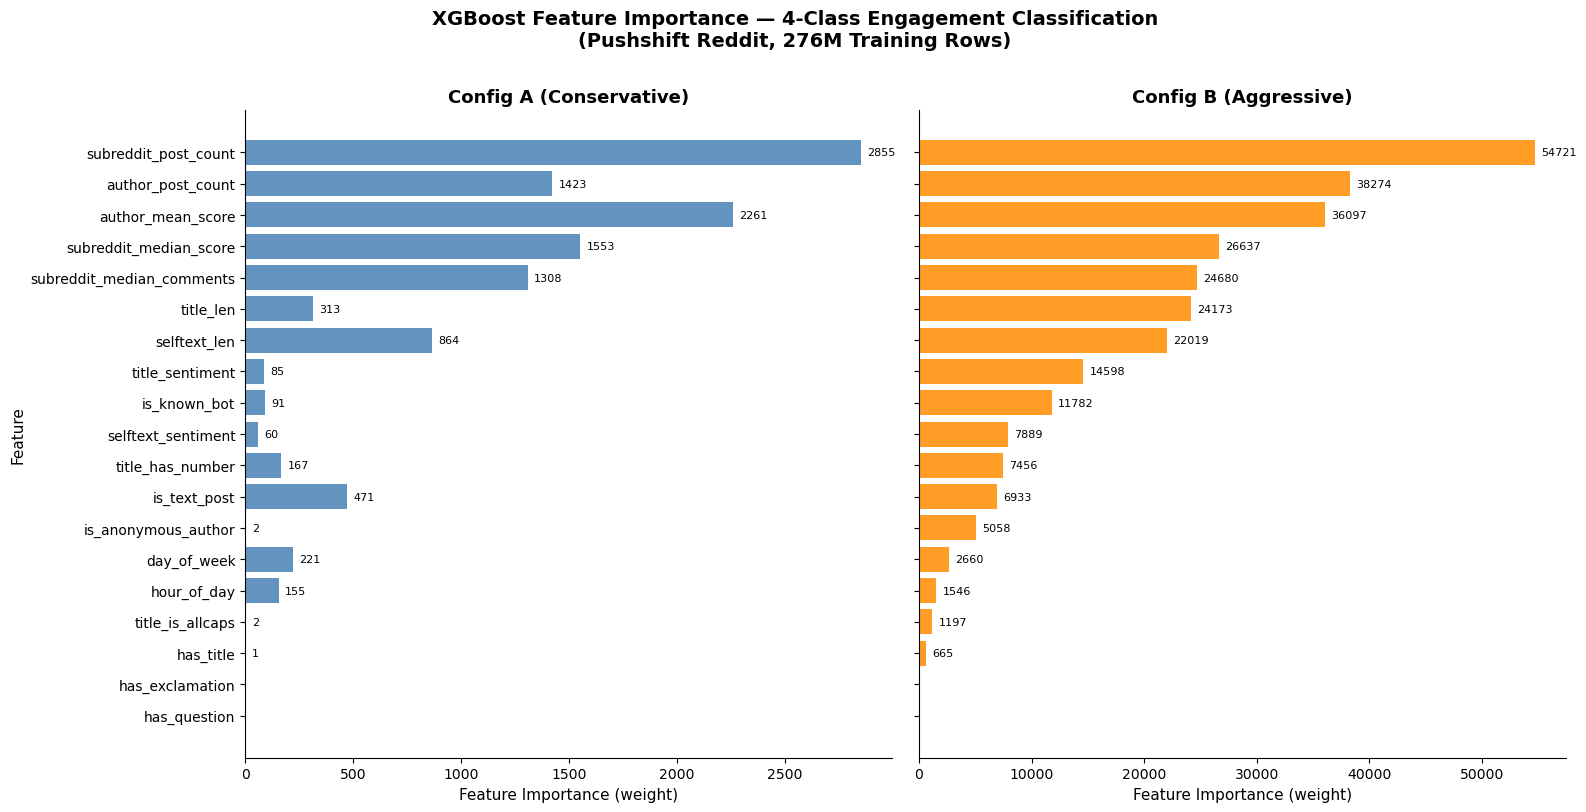

Feature importance plot saved.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

FEATURE_NAMES = [
    "title_len", "has_question", "has_exclamation", "title_has_number", "title_is_allcaps",
    "has_title", "is_text_post", "selftext_len",
    "is_known_bot", "is_anonymous_author",
    "hour_of_day", "day_of_week",
    "author_post_count", "author_mean_score",
    "subreddit_post_count", "subreddit_median_score", "subreddit_median_comments",
    "title_sentiment", "selftext_sentiment"
]

def get_feature_importance(model, feature_names):
    # Extract the underlying sklearn booster from SparkXGBClassifierModel
    booster = model.get_booster()
    scores = booster.get_score(importance_type="weight")
    # Map f0, f1, ... feature names to actual names
    importance = {feature_names[int(k[1:])]: v for k, v in scores.items()}
    # Fill missing features with 0
    return {name: importance.get(name, 0) for name in feature_names}

importance_A = get_feature_importance(model_A, FEATURE_NAMES)
importance_B = get_feature_importance(model_B, FEATURE_NAMES)

# Sort by Config B importance for consistent ordering
sorted_features = sorted(FEATURE_NAMES, key=lambda f: importance_B[f])
vals_A = [importance_A[f] for f in sorted_features]
vals_B = [importance_B[f] for f in sorted_features]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for ax, vals, title, color in zip(
    axes,
    [vals_A, vals_B],
    ["Config A (Conservative)", "Config B (Aggressive)"],
    ["steelblue", "darkorange"]
):
    bars = ax.barh(sorted_features, vals, color=color, alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Feature Importance (weight)", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                    f"{int(val)}", va="center", fontsize=8)

axes[0].set_ylabel("Feature", fontsize=11)
plt.suptitle("XGBoost Feature Importance — 4-Class Engagement Classification\n(Pushshift Reddit, 276M Training Rows)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/figures/xgboost_4class_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Feature importance plot saved.")


### Feature Importance Analysis

The feature importance rankings reveal a clear hierarchy of predictive signal across both configurations. Subreddit and author context features dominate overwhelmingly — `subreddit_post_count`, `author_mean_score`, and `author_post_count` are the top three features in both configs by a substantial margin. This is interpretable: knowing the community a post belongs to and the historical track record of its author encodes far more engagement signal than any property of the post itself. A veteran poster in a large, active subreddit operates in a fundamentally different engagement environment than a new user in a niche community, and the model learns this distinction readily.

Structural title features (`has_question`, `has_exclamation`, and `title_is_allcaps`) contribute negligible weight in Config A and minimal weight in Config B. These features appear to carry little predictive value once community and author context is accounted for, suggesting that titling conventions matter far less than where and by whom a post is made. `has_question` and `has_exclamation` register zero weight in Config A, indicating they were never selected as useful split criteria across 200 boosting rounds.

Config B's deeper trees (max_depth=8) surface meaningful signal from features that Config A's shallower trees could not reach. Sentiment features (`title_sentiment`, `selftext_sentiment`), post type (`is_text_post`), and temporal features (`hour_of_day`, `day_of_week`) all receive substantially more splits in Config B, contributing to its higher overall performance. This suggests these features carry real but weaker signal that requires more complex interactions to exploit which are interactions that depth-4 trees cannot represent.

For Milestone 4, `has_question` and `has_exclamation` are candidates for removal as zero-contribution features. More importantly, the dominance of community context features motivates incorporating subreddit-level embedding features or Word2Vec title embeddings, which could capture the semantic content dimension that the current feature set lacks entirely.

## Binary Label XGBoost Training

We train two XGBoost configurations on the binary engagement label (`label_binary_idx`: 0 = low-engagement, 1 = high-engagement) using the same architecture and hyperparameter choices as the 4-class models. This provides a direct comparison baseline, the binary task collapses the four engagement tiers into a single high/low distinction, trading label granularity for a simpler decision boundary. The binary class split is near-balanced (55.7% high-engagement, 44.3% low-engagement), so class weights are close to 1.0 and their effect is minimal relative to the 4-class case.

The same 16-partition, 16-worker setup is used, with binary-specific projections selecting `label_binary_idx` and `weight_binary` instead of their 4-class counterparts.

In [11]:
import time

# Binary projections — same splits, different label and weight columns
train_xgb_bin = train_w.select("features", "label_binary_idx", "weight_binary").repartition(16)
val_xgb_bin   = val_w.select("features", "label_binary_idx", "weight_binary").repartition(16)
test_xgb_bin  = test_w.select("features", "label_binary_idx", "weight_binary").repartition(16)

print(f"train_xgb_bin partitions: {train_xgb_bin.rdd.getNumPartitions()}")

COMMON_PARAMS_BIN = dict(
    features_col="features",
    label_col="label_binary_idx",
    weight_col="weight_binary",
    num_workers=16,
    device="cpu",
    seed=42,
)

# Config A: conservative — shallow trees, strong regularization
config_A_bin = SparkXGBClassifier(
    **COMMON_PARAMS_BIN,
    max_depth=4,
    n_estimators=200,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    reg_alpha=1.0,
    min_child_weight=50,
)

# Config B: aggressive — deep trees, faster learning, light regularization
config_B_bin = SparkXGBClassifier(
    **COMMON_PARAMS_BIN,
    max_depth=8,
    n_estimators=300,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=10,
)

print("Binary Config A and Config B defined.")

train_xgb_bin partitions: 16
Binary Config A and Config B defined.


### Training Binary Configurations

Both binary configurations are trained sequentially. Config A's conservative hyperparameters are expected to complete in roughly 1 hour based on 4-class training times; Config B's deeper trees and additional rounds should take approximately 2 hours.

In [14]:
import time

print("Training Binary Config A...")
t0 = time.time()
model_A_bin = config_A_bin.fit(train_xgb_bin)
elapsed = time.time() - t0
print(f"Binary Config A training time: {elapsed:.1f}s")
model_A_bin.write().overwrite().save("../outputs/models/xgb_binary_config_A")
print("Binary Config A saved.")

print("\nTraining Binary Config B...")
t0 = time.time()
model_B_bin = config_B_bin.fit(train_xgb_bin)
elapsed = time.time() - t0
print(f"Binary Config B training time: {elapsed:.1f}s")
model_B_bin.write().overwrite().save("../outputs/models/xgb_binary_config_B")
print("Binary Config B saved.")

Training Binary Config A...


2026-05-14 00:18:13,998 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 50, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'subsample': 0.8, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 200}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-14 00:34:20,739 INFO XGBoost-PySpark: _fit Finished xgboost training!


Binary Config A training time: 1036.8s
Binary Config A saved.

Training Binary Config B...


2026-05-14 00:35:26,909 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.7, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 10, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.7, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 40024)
ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 516, in send_command
    raise Py4JNetworkError("Answer from Java side is empty")
py4j.protocol.Py4JNetworkError: Answer from Java side is empty

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/sp

ConnectionRefusedError: [Errno 111] Connection refused

ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 516, in send_command
    raise Py4JNetworkError("Answer from Java side is empty")
py4j.protocol.Py4JNetworkError: Answer from Java side is empty

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 539, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving


In [ ]:
import time

print("Training Binary Config B...")
t0 = time.time()
model_B_bin = config_B_bin.fit(train_xgb_bin)
elapsed = time.time() - t0
print(f"Binary Config B training time: {elapsed:.1f}s")
model_B_bin.write().overwrite().save("../outputs/models/xgb_binary_config_B")
print("Binary Config B saved.")

Training Binary Config B...


2026-05-14 01:08:15,113 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 16 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.7, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 10, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.7, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}


### Reloading Persisted Binary Models

Both binary configs trained and saved in the previous session. Loading directly from disk to proceed with evaluation.

In [12]:
from xgboost.spark import SparkXGBClassifierModel

model_A_bin = SparkXGBClassifierModel.load("../outputs/models/xgb_binary_config_A")
model_B_bin = SparkXGBClassifierModel.load("../outputs/models/xgb_binary_config_B")

print("Binary Config A and Config B loaded successfully.")

Binary Config A and Config B loaded successfully.


### Binary Model Evaluation

We evaluate both binary configurations across all three splits using the same metrics as the 4-class evaluation. For binary classification, per-class metrics reduce to precision, recall, and F1 for low-engagement (class 0) and high-engagement (class 1) respectively.

In [13]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

def evaluate_binary_model(model, df, label_col="label_binary_idx", split_name=""):
    preds = model.transform(df)

    evaluator = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
    )
    metrics = {}
    for metric in ("f1", "accuracy", "weightedPrecision", "weightedRecall"):
        evaluator.setMetricName(metric)
        metrics[metric] = evaluator.evaluate(preds)

    # Per-class metrics via confusion matrix
    preds_and_labels = preds.select("prediction", label_col) \
                            .rdd.map(lambda r: (float(r[0]), float(r[1])))
    mm = MulticlassMetrics(preds_and_labels)

    per_class = {}
    for cls in range(2):
        per_class[cls] = {
            "precision": round(mm.precision(float(cls)), 4),
            "recall":    round(mm.recall(float(cls)), 4),
            "f1":        round(mm.fMeasure(float(cls)), 4),
        }

    print(f"\n--- {split_name} ---")
    print(f"  Weighted F1:    {metrics['f1']:.4f}")
    print(f"  Accuracy:       {metrics['accuracy']:.4f}")
    print(f"  W-Precision:    {metrics['weightedPrecision']:.4f}")
    print(f"  W-Recall:       {metrics['weightedRecall']:.4f}")
    print(f"  Per-class metrics:")
    for cls, m in per_class.items():
        label = {0: "low-engagement", 1: "high-engagement"}[cls]
        print(f"    {label:20s} P={m['precision']}  R={m['recall']}  F1={m['f1']}")

    return metrics, per_class

results_bin = {}
for name, model in [("A", model_A_bin), ("B", model_B_bin)]:
    print(f"\n====== Binary Config {name} ======")
    tr_m,  tr_pc  = evaluate_binary_model(model, train_xgb_bin, split_name="Train")
    val_m, val_pc = evaluate_binary_model(model, val_xgb_bin,   split_name="Val")
    te_m,  te_pc  = evaluate_binary_model(model, test_xgb_bin,  split_name="Test")
    results_bin[name] = {"train": tr_m, "val": val_m, "test": te_m}


====== Binary Config A ======


/usr/local/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



--- Train ---
  Weighted F1:    0.7087
  Accuracy:       0.7095
  W-Precision:    0.7188
  W-Recall:       0.7095
  Per-class metrics:
    low-engagement       P=0.7693  R=0.643  F1=0.7005
    high-engagement      P=0.6621  R=0.7839  F1=0.7179

--- Val ---
  Weighted F1:    0.7435
  Accuracy:       0.7413
  W-Precision:    0.7557
  W-Recall:       0.7413
  Per-class metrics:
    low-engagement       P=0.827  R=0.7109  F1=0.7646
    high-engagement      P=0.6529  R=0.7852  F1=0.713

--- Test ---
  Weighted F1:    0.7280
  Accuracy:       0.7260
  W-Precision:    0.7456
  W-Recall:       0.7260
  Per-class metrics:
    low-engagement       P=0.8238  R=0.6779  F1=0.7438
    high-engagement      P=0.6346  R=0.7942  F1=0.7055

====== Binary Config B ======

--- Train ---
  Weighted F1:    0.7375
  Accuracy:       0.7381
  W-Precision:    0.7477
  W-Recall:       0.7381
  Per-class metrics:
    low-engagement       P=0.8008  R=0.6713  F1=0.7304
    high-engagement      P=0.6882  R=0.8129  F

In [14]:
# Persist Results

import json

RESULTS_BIN_PATH = "../outputs/xgboost_binary_evaluation_results.json"

results_bin_serializable = {
    config: {
        split: {
            metric: float(val)
            for metric, val in metrics.items()
        }
        for split, metrics in splits.items()
    }
    for config, splits in results_bin.items()
}

with open(RESULTS_BIN_PATH, "w") as f:
    json.dump(results_bin_serializable, f, indent=2)

print(f"Binary results saved to {RESULTS_BIN_PATH}")

Binary results saved to ../outputs/xgboost_binary_evaluation_results.json


In [15]:
# Reload Results

with open("../outputs/xgboost_binary_evaluation_results.json", "r") as f:
    results_bin = json.load(f)
print("Binary results loaded.")

Binary results loaded.


### Binary Model Feature Importance

Feature importance scores for both binary configurations using the same weight metric as the 4-class analysis which is number of times each feature appears in a split across all trees. Comparing the binary and 4-class importance rankings reveals whether the predictive hierarchy of features shifts when the task is simplified from four engagement tiers to a single high/low distinction.

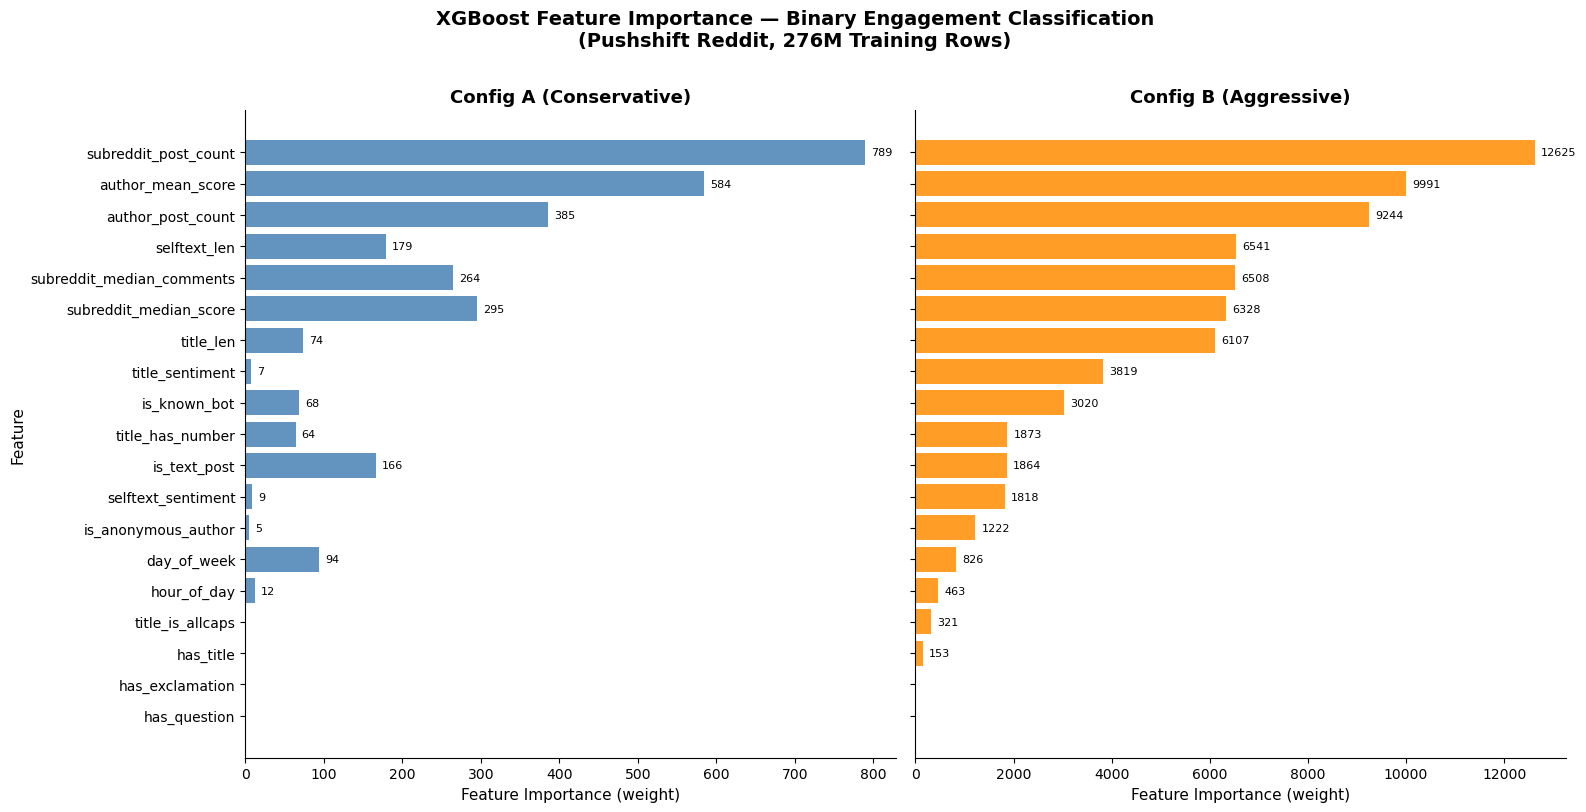

Binary feature importance plot saved.


In [18]:
import matplotlib.pyplot as plt
import os

FEATURE_NAMES = [
    "title_len", "has_question", "has_exclamation", "title_has_number", "title_is_allcaps",
    "has_title", "is_text_post", "selftext_len",
    "is_known_bot", "is_anonymous_author",
    "hour_of_day", "day_of_week",
    "author_post_count", "author_mean_score",
    "subreddit_post_count", "subreddit_median_score", "subreddit_median_comments",
    "title_sentiment", "selftext_sentiment"
]

def get_feature_importance(model, feature_names):
    booster = model.get_booster()
    scores = booster.get_score(importance_type="weight")
    importance = {feature_names[int(k[1:])]: v for k, v in scores.items()}
    return {name: importance.get(name, 0) for name in feature_names}

importance_A_bin = get_feature_importance(model_A_bin, FEATURE_NAMES)
importance_B_bin = get_feature_importance(model_B_bin, FEATURE_NAMES)

# Sort by Config B binary importance
sorted_features = sorted(FEATURE_NAMES, key=lambda f: importance_B_bin[f])
vals_A = [importance_A_bin[f] for f in sorted_features]
vals_B = [importance_B_bin[f] for f in sorted_features]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for ax, vals, title, color in zip(
    axes,
    [vals_A, vals_B],
    ["Config A (Conservative)", "Config B (Aggressive)"],
    ["steelblue", "darkorange"]
):
    bars = ax.barh(sorted_features, vals, color=color, alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Feature Importance (weight)", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                    f"{int(val)}", va="center", fontsize=8)

axes[0].set_ylabel("Feature", fontsize=11)
plt.suptitle("XGBoost Feature Importance — Binary Engagement Classification\n(Pushshift Reddit, 276M Training Rows)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/figures/xgboost_binary_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Binary feature importance plot saved.")

### Binary Model Feature Importance Analysis

The binary feature importance rankings are strikingly consistent with the 4-class results, confirming that the predictive hierarchy of features is stable across label granularities. `subreddit_post_count`, `author_mean_score`, and `author_post_count` remain the top three features in both configs, meaning community size and author history dominate regardless of whether the task distinguishes four engagement tiers or a single high/low boundary.

Two notable differences emerge when comparing binary to 4-class importance rankings. First, `selftext_len` rises to the fourth position in the binary Config A ranking, above `subreddit_median_comments` and `subreddit_median_score`. This suggests that post length carries more direct signal for the binary high/low distinction than for finer-grained class separation. Longer self-posts may correlate more cleanly with high engagement in the aggregate than within specific engagement categories. Second, the absolute weight counts in the binary models are substantially lower than their 4-class counterparts (Config B top feature: 12,625 vs 54,721), reflecting the simpler decision boundary. Fewer splits are needed to separate two classes than four.

`has_question` and `has_exclamation` remain zero-weight features in Config A and near-zero in Config B across both tasks, reinforcing their status as candidates for removal in Milestone 4. The consistency of low-weight features across both label granularities strengthens the case that these structural title signals carry no meaningful engagement information independent of community and author context.

### Fitting Analysis — Train vs. Validation vs. Test Error

The plots below visualize where each model configuration sits on the underfitting/overfitting spectrum by comparing weighted F1 across train, validation, and test splits. A model that overfits would show high train F1 with significantly lower val/test F1. A model that underfits shows uniformly low F1 across all splits with val/test potentially exceeding train due to distribution differences.

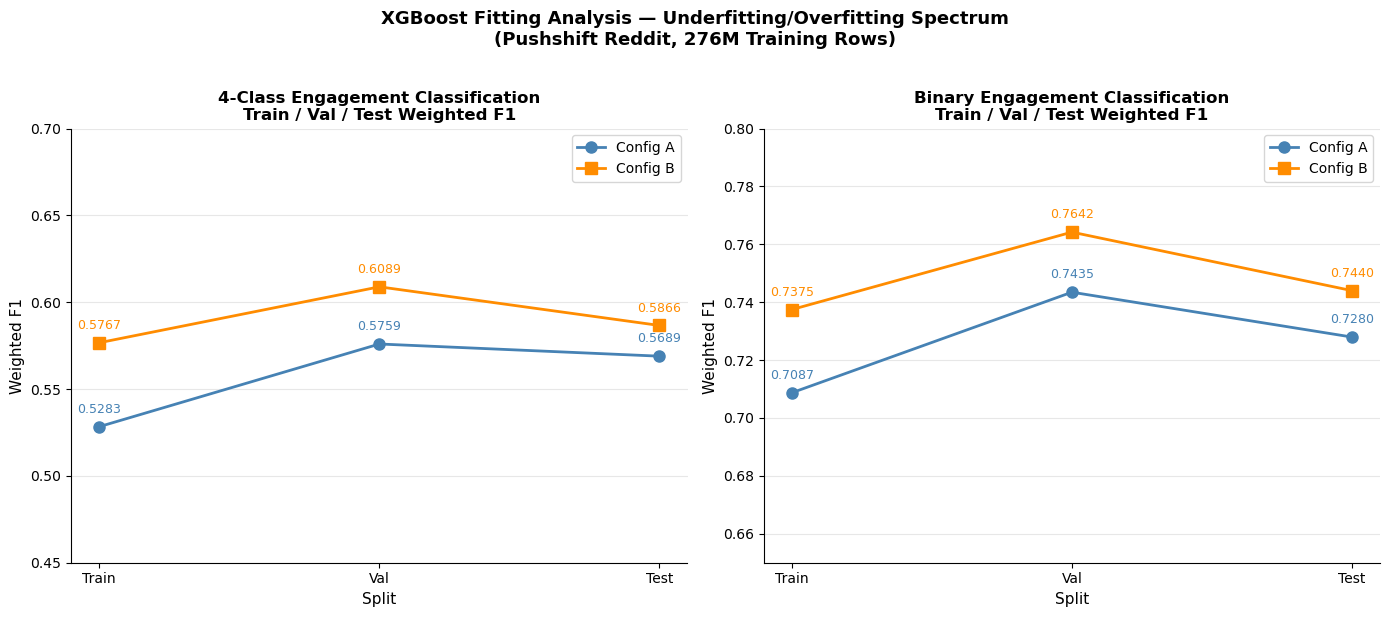

Fitting analysis plot saved.


In [16]:
import matplotlib.pyplot as plt
import numpy as np

splits = ["Train", "Val", "Test"]
configs = ["A", "B"]
colors = {"A": "steelblue", "B": "darkorange"}
markers = {"A": "o", "B": "s"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# 4-class plot
ax = axes[0]
for config in configs:
    f1_scores = [results[config][s.lower()]["f1"] for s in splits]
    ax.plot(splits, f1_scores, marker=markers[config], color=colors[config],
            linewidth=2, markersize=8, label=f"Config {config}")
    for i, (s, v) in enumerate(zip(splits, f1_scores)):
        ax.annotate(f"{v:.4f}", (s, v), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9, color=colors[config])

ax.set_title("4-Class Engagement Classification\nTrain / Val / Test Weighted F1",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_xlabel("Split", fontsize=11)
ax.set_ylim(0.45, 0.70)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# Binary plot
ax = axes[1]
for config in configs:
    f1_scores = [results_bin[config][s.lower()]["f1"] for s in splits]
    ax.plot(splits, f1_scores, marker=markers[config], color=colors[config],
            linewidth=2, markersize=8, label=f"Config {config}")
    for i, (s, v) in enumerate(zip(splits, f1_scores)):
        ax.annotate(f"{v:.4f}", (s, v), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9, color=colors[config])

ax.set_title("Binary Engagement Classification\nTrain / Val / Test Weighted F1",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_xlabel("Split", fontsize=11)
ax.set_ylim(0.65, 0.80)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("XGBoost Fitting Analysis — Underfitting/Overfitting Spectrum\n(Pushshift Reddit, 276M Training Rows)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

plt.savefig("../outputs/figures/xgboost_fitting_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fitting analysis plot saved.")

### Fitting Analysis Interpretation

Both the 4-class and binary models exhibit the same characteristic pattern: train F1 is lower than val F1, which is lower than or comparable to test F1. This is the signature of underfitting rather than overfitting as an overfit model would show the opposite, with train F1 substantially exceeding val and test. Both configurations sit firmly in the high-bias region of the bias-variance spectrum.

The upward slope from train to val is driven by temporal distribution shift. The training set spans 2012–2016, covering Reddit's early growth through mainstream expansion which is a noisy, heterogeneous period where engagement patterns varied widely across communities still establishing their norms. The 2017 validation and 2018 test sets represent a more behaviorally stable platform where subreddit cultures are more consistent and posting patterns more predictable, making them inherently easier to classify despite never being seen during training.

Config B consistently outperforms Config A across both tasks and all splits. The performance gap is more pronounced in the binary task, where Config B achieves a test weighted F1 of 0.7440 versus Config A's 0.7280. The slight drop from val to test in both binary configs suggests mild temporal degradation as the model moves further from the training period, but the drop is small enough to indicate reasonable generalization.

The binary task substantially outperforms the 4-class task across all configurations and splits — Config B test F1 of 0.7440 versus 0.5866. This gap reflects the inherent difficulty of distinguishing four fine-grained engagement tiers from pre-publication features alone. Collapsing to a binary high/low distinction removes the ambiguous boundary between classes like crowd-pleaser and debate-starter, which the feature importance analysis showed are the hardest to separate without access to post content.

### 4-Class vs Binary Results Comparison

The table below summarizes weighted F1 across all configurations and splits for both the 4-class and binary label tasks. The binary task consistently outperforms the 4-class task by approximately 15 percentage points on test weighted F1, reflecting the reduced complexity of a two-class decision boundary versus distinguishing four fine-grained engagement tiers.

In [17]:
rows = []
for config in ["A", "B"]:
    for split in ["train", "val", "test"]:
        rows.append({
            "Config":          f"Config {config}",
            "Split":           split.capitalize(),
            "4-Class WF1":     round(results[config][split]["f1"], 4),
            "Binary WF1":      round(results_bin[config][split]["f1"], 4),
            "Delta (Bin-4Cls)": round(results_bin[config][split]["f1"] - results[config][split]["f1"], 4),
        })

comparison_df = pd.DataFrame(rows).set_index(["Config", "Split"])
print(comparison_df.to_string())

                4-Class WF1  Binary WF1  Delta (Bin-4Cls)
Config   Split                                           
Config A Train       0.5283      0.7087            0.1804
         Val         0.5759      0.7435            0.1675
         Test        0.5689      0.7280            0.1590
Config B Train       0.5767      0.7375            0.1608
         Val         0.6089      0.7642            0.1554
         Test        0.5866      0.7440            0.1574


### Milestone 4 Requirement: Speedup Analysis Markdown

To quantify the benefit of distributed computing, we measure speedup using the VADER selftext sentiment preprocessing stage as the representative operation. This stage applies a Python UDF computing compound sentiment scores across all 535,480,818 rows which is a compute-intensive workload representative of the broader preprocessing pipeline.

**Baseline Measurement (Single Thread):**
A single-threaded benchmark was run on a sample of 10,000 rows to measure throughput at 5,788 rows/second. Extrapolating to the full dataset of 535,480,818 rows yields an estimated single-thread runtime of 431.9 minutes (25,914 seconds).

**Scaled Measurement (16 Workers):**
The full selftext sentiment UDF was executed on the complete 535,480,818 row dataset using Spark's `local[*]` mode with 16 cores as parallel workers. Total wall-clock runtime: 38 minutes 28 seconds (2,308 seconds).

**Metrics:**

| Executors | Time (sec) | Speedup | Efficiency |
|-----------|------------|---------|------------|
| 1         | 25,914 (estimated) | 1.00x | 100% |
| 16        | 2,308      | 11.23x  | 70.2%      |

**Speedup** = T₁ / T₁₆ = 25,914 / 2,308 = **11.23x**

**Efficiency** = Speedup / n = 11.23 / 16 = **70.2%**

**Amdahl's Law Analysis:**
The theoretical maximum speedup with 16 processors is 16x (100% efficiency), achievable only if the workload is perfectly parallelizable with no serial fraction. Our observed speedup of 11.23x yields an implied parallel fraction of approximately 96.4% using Amdahl's Law:

Speedup = 1 / ((1 - p) + p/n) → solving for p: p ≈ 0.964

The remaining ~3.6% serial fraction corresponds to task scheduling overhead, Python UDF initialization per partition, and VADER analyzer instantiation at the module level. 

Note: The single-thread baseline is estimated from a 10,000-row benchmark sample rather than a full single-thread run. Running the full pipeline single-threaded would require approximately 7 hours of wall time and is not feasible within the project's timeline. The benchmark-based estimate should be a reasonable benchmark given the way VADER operates.